<a href = "https://docs.google.com/document/d/1nOhYKYrC2X6G8cBD_ebGnO3Y_xkFlLW2NgpWMuky2oU/edit?tab=t.0#heading=h.fkeeuf50kpu8"> 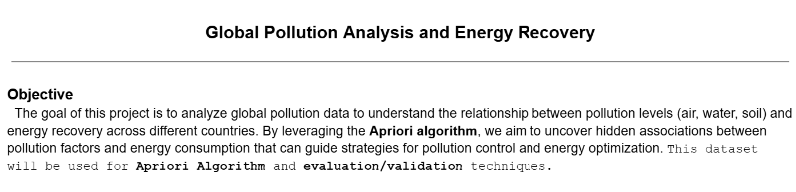</a>

Step 1 - Data Import and Preprocessing


In [42]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('Global_Pollution_Analysis.csv')

In [44]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [45]:
df.shape

(200, 13)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

NO - NULL 

In [47]:
(df == "").sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df_new = df.copy()

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])

     

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new['Country'] = le.fit_transform(df['Country'])
df_new['Year'] = le.fit_transform(df['Year'])
     

In [52]:
df_new.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,92,4,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,11,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,41,10,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


In [53]:
df.sort_values(by='Year')['Year']

14     2000
10     2000
25     2000
39     2000
42     2000
       ... 
62     2019
169    2019
132    2019
131    2019
157    2019
Name: Year, Length: 200, dtype: int64

So data is from year 2000 to 2019 

Step 2 - Exploratory Data Analysis (EDA)


In [54]:
df_new.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [55]:
df.dtypes

Country                                       str
Year                                        int64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
dtype: object

In [56]:
# df.describe().corr()

In [57]:
correlation = df_new.corr(numeric_only=True)["Energy_Recovered (in GWh)"]
correlation

Country                                  -0.044316
Year                                      0.088332
Air_Pollution_Index                       0.002997
Water_Pollution_Index                    -0.041828
Soil_Pollution_Index                      0.064076
Industrial_Waste (in tons)               -0.161309
Energy_Recovered (in GWh)                 1.000000
CO2_Emissions (in MT)                     0.024758
Renewable_Energy (%)                      0.043533
Plastic_Waste_Produced (in tons)         -0.072946
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Population (in millions)                 -0.075100
GDP_Per_Capita (in USD)                   0.004535
Name: Energy_Recovered (in GWh), dtype: float64

<Axes: >

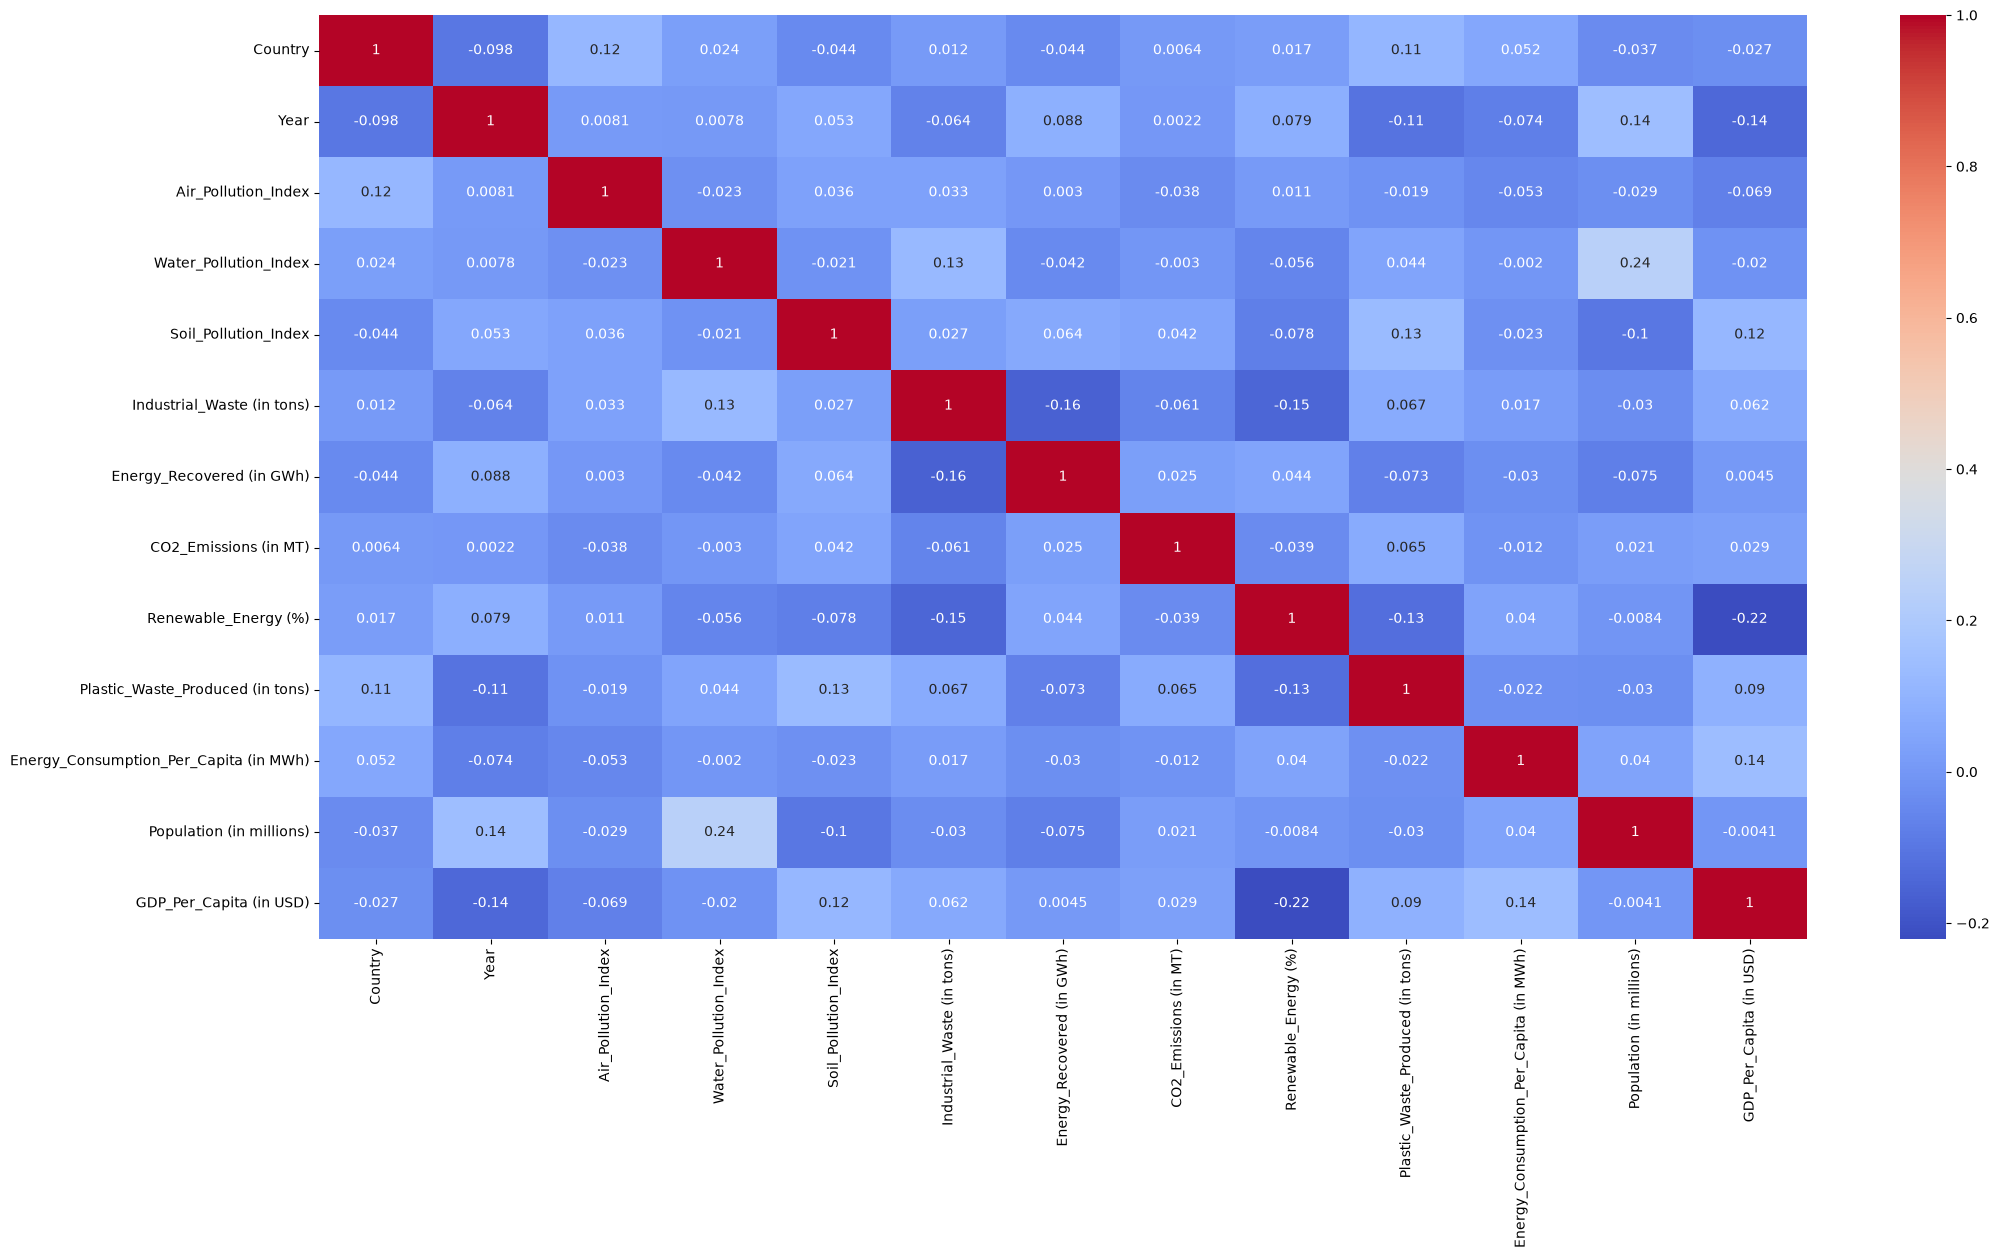

In [58]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True ,cmap = "coolwarm")

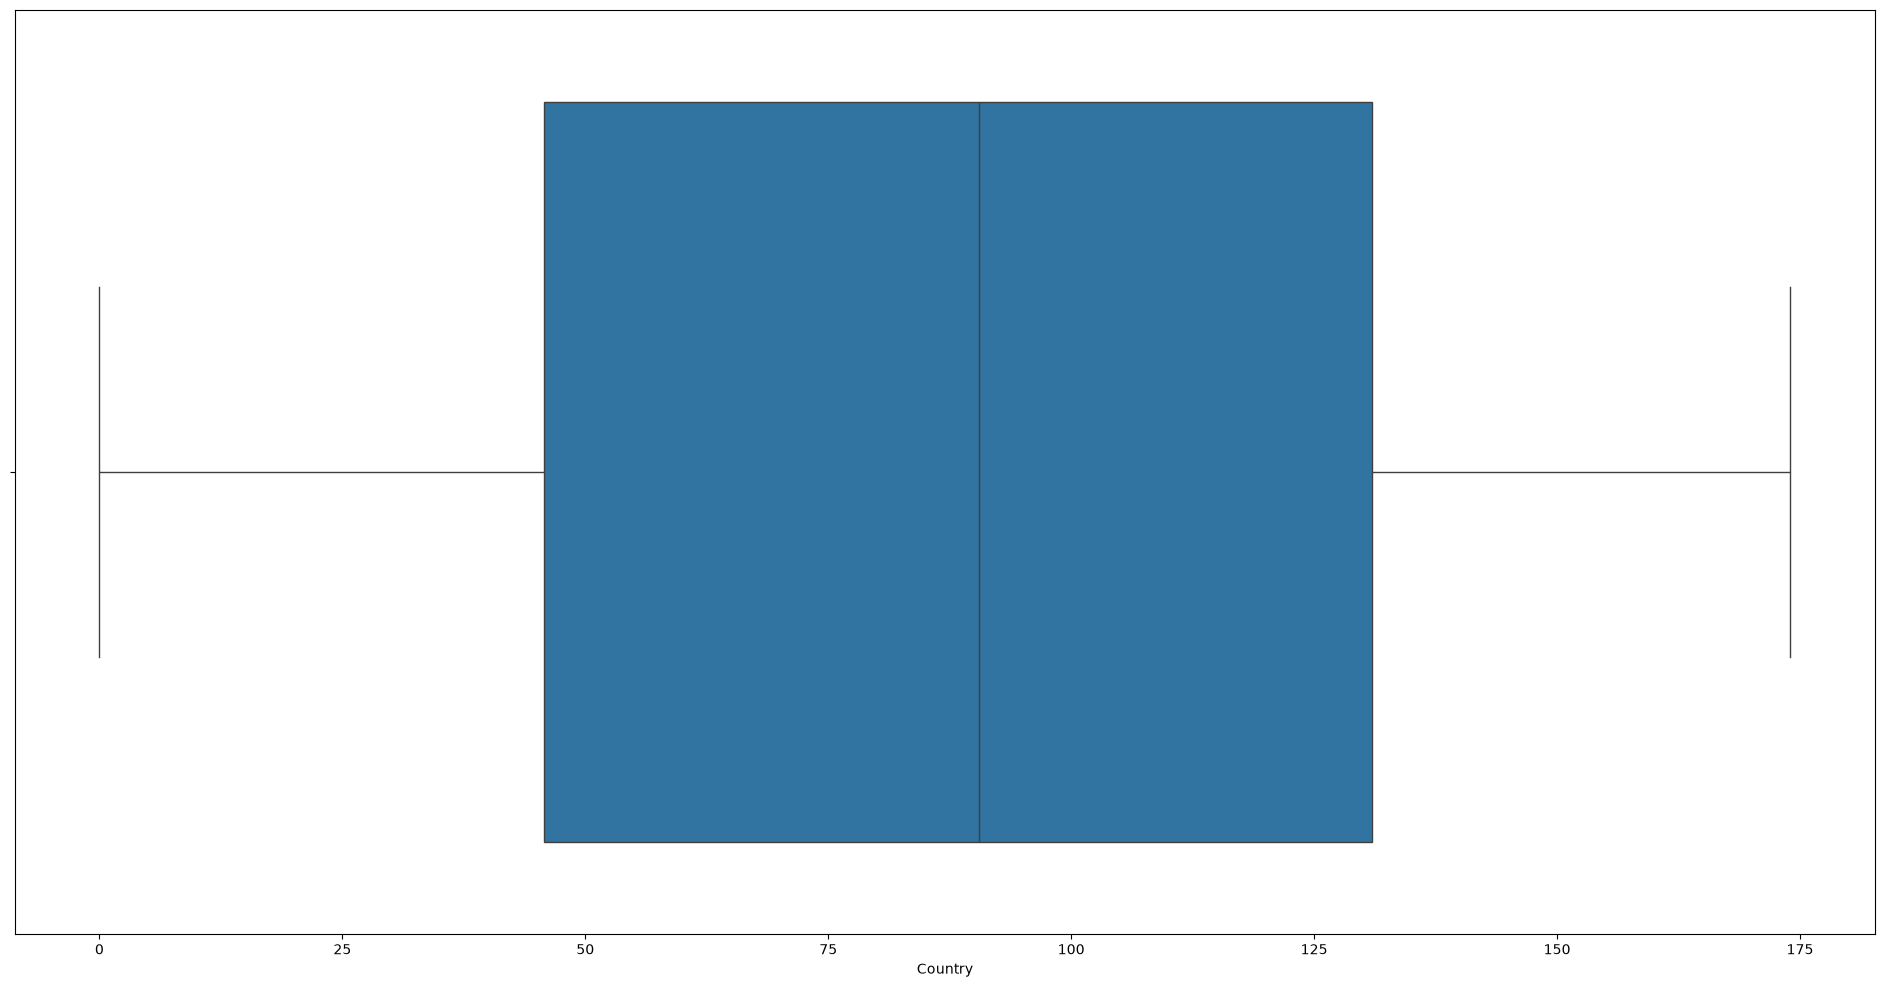

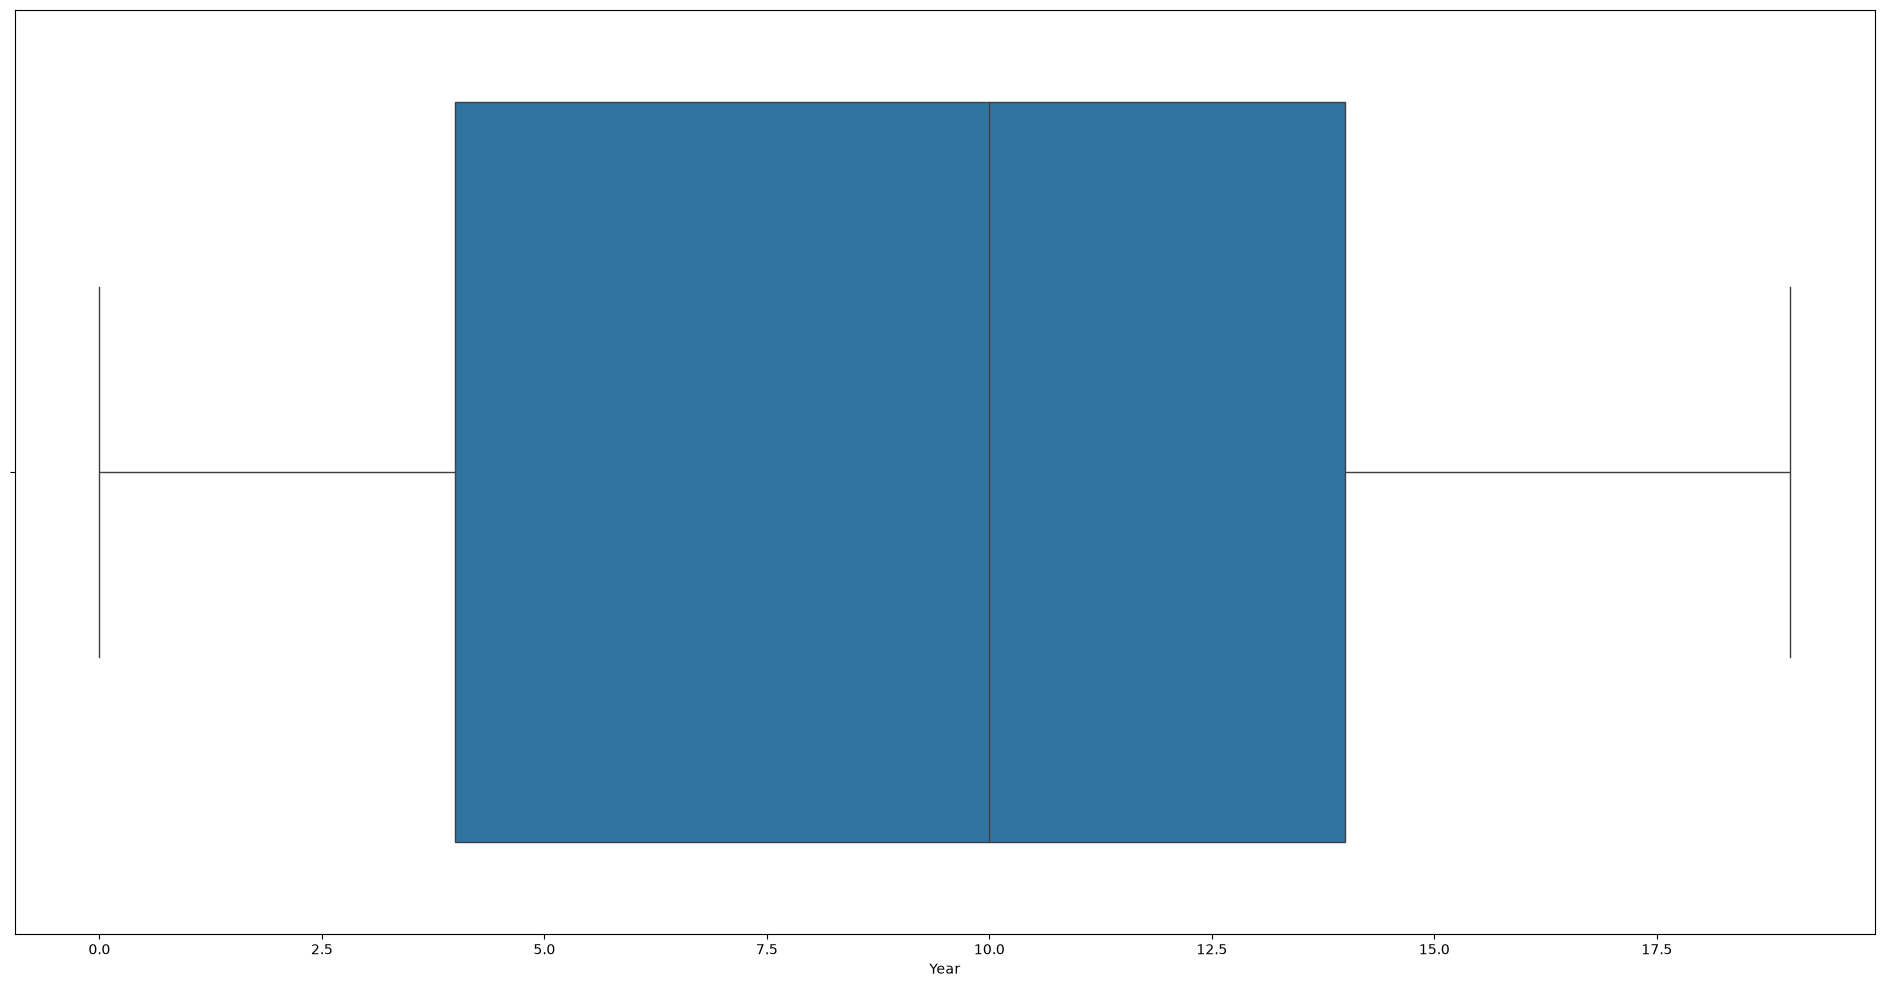

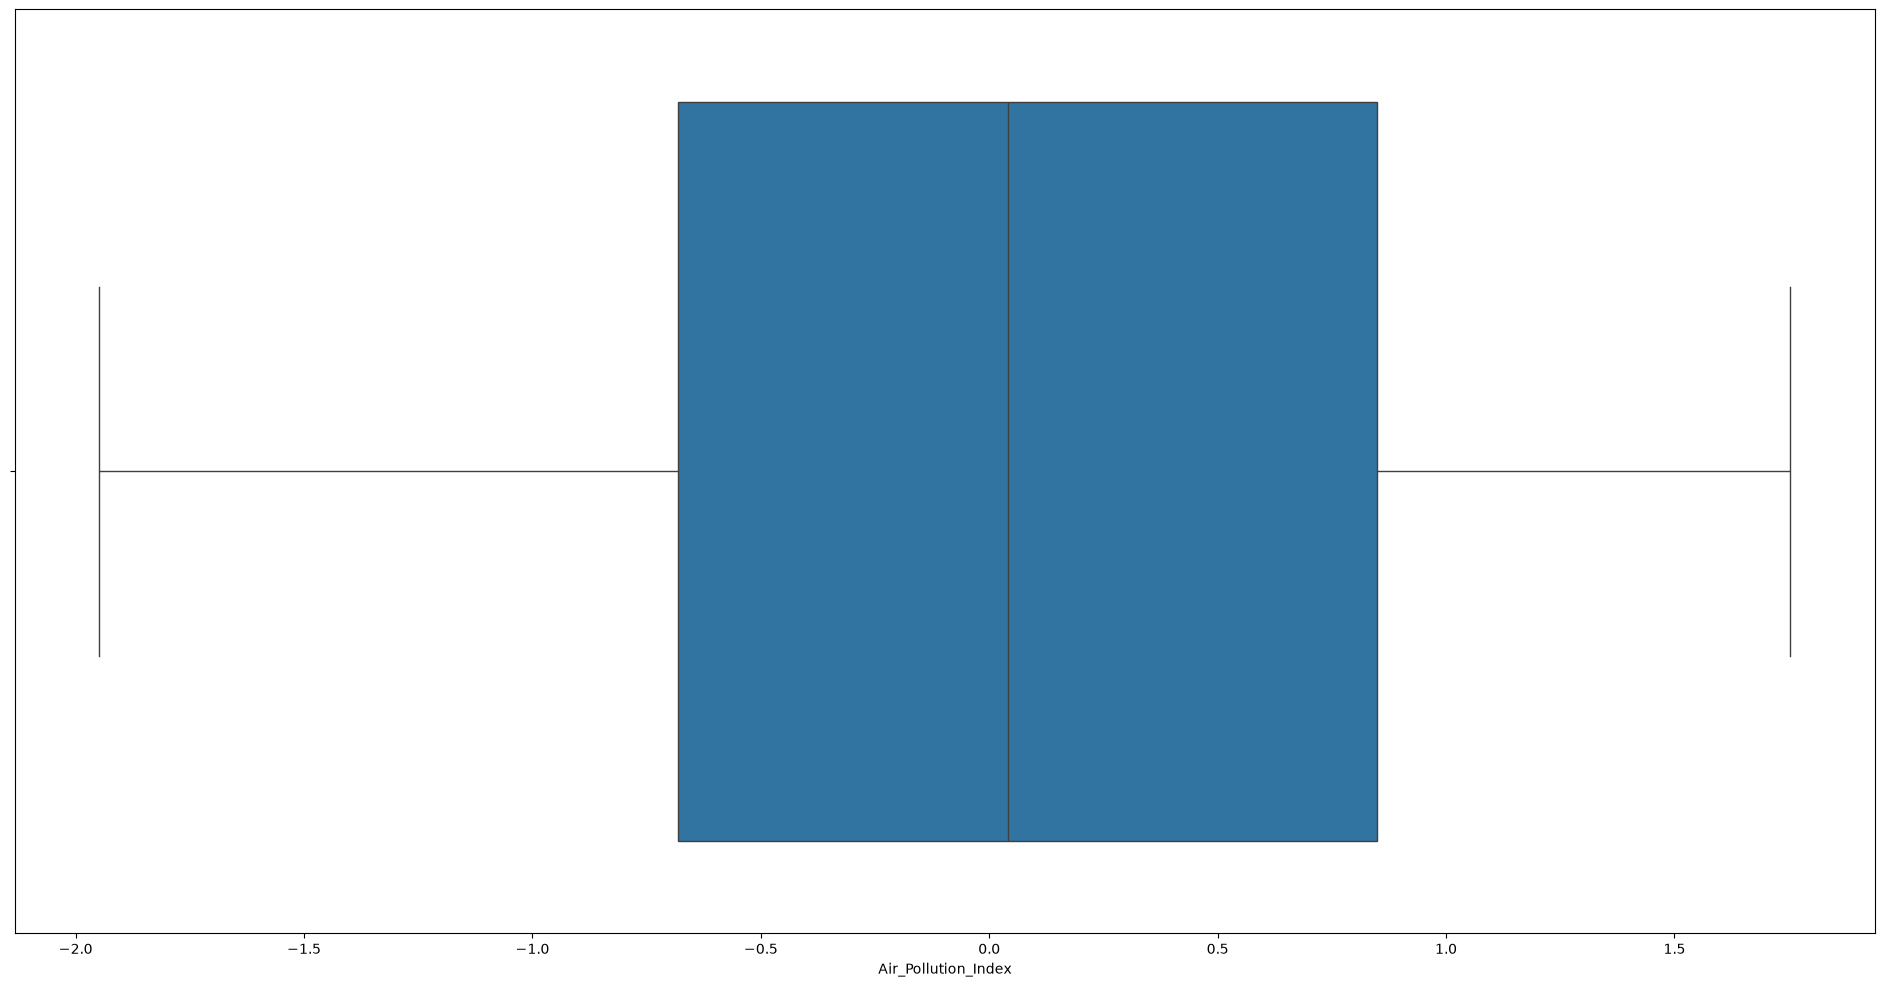

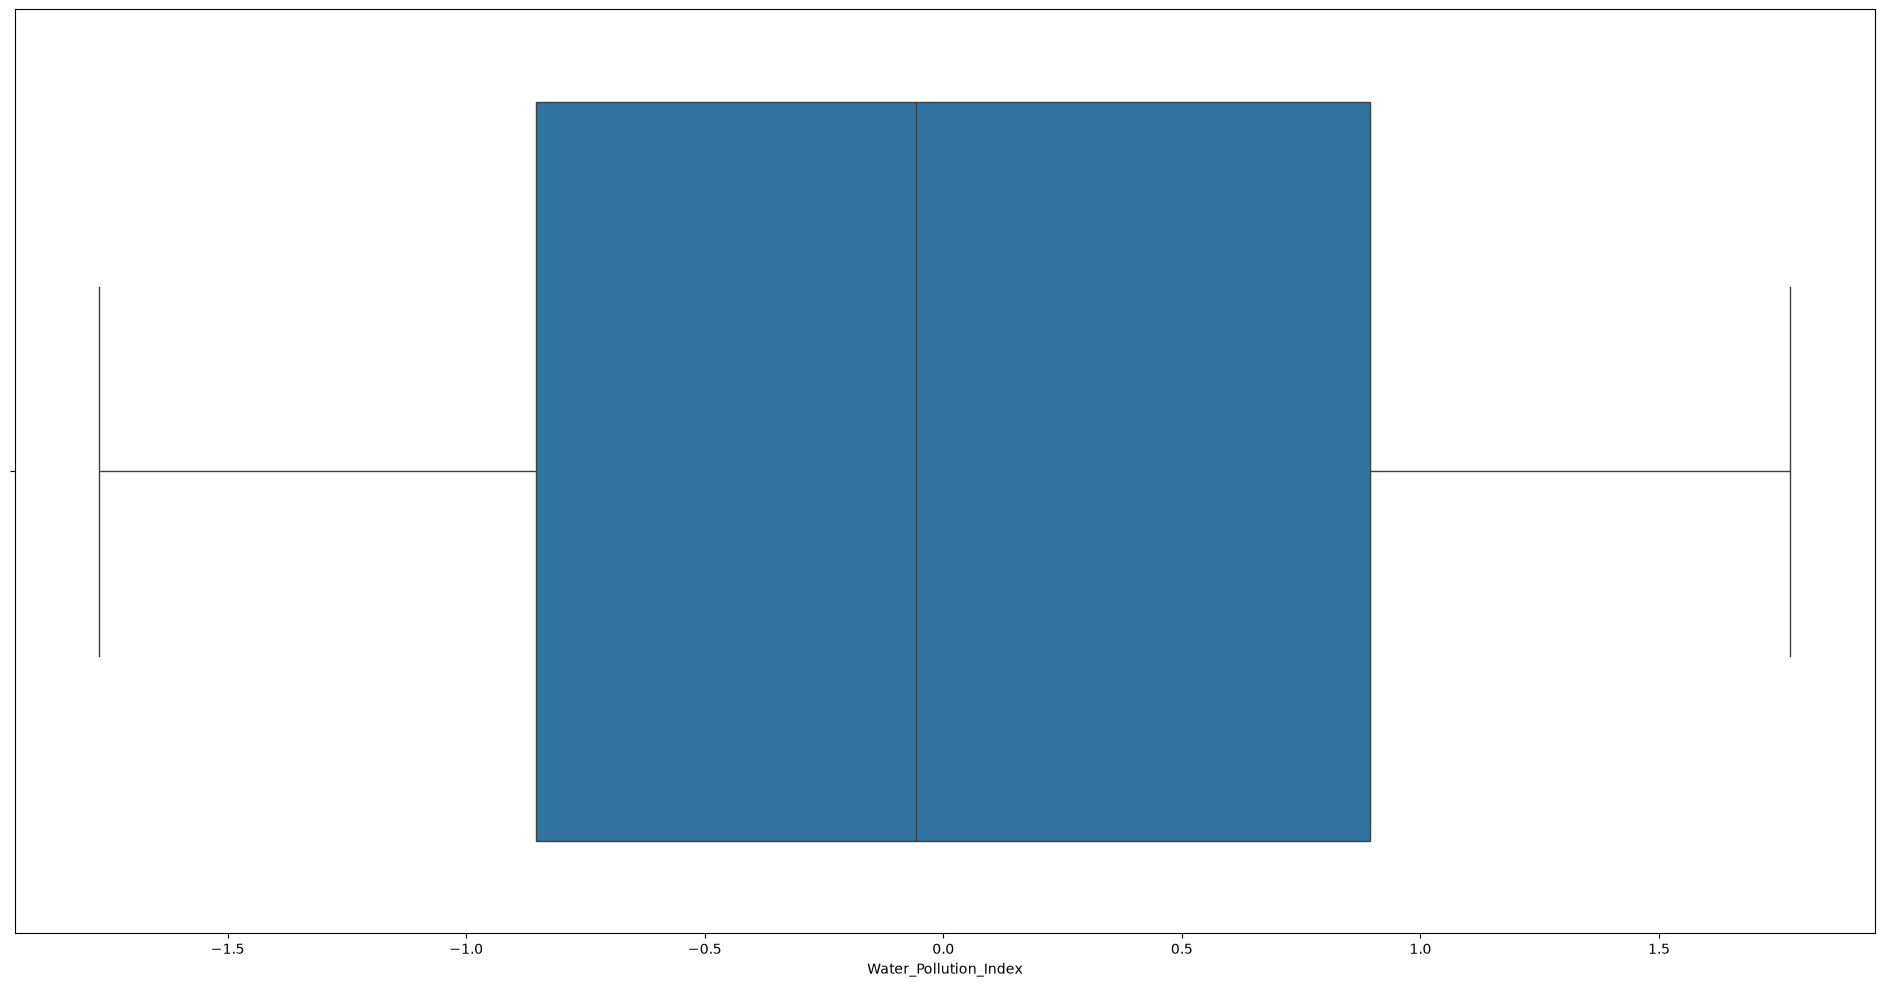

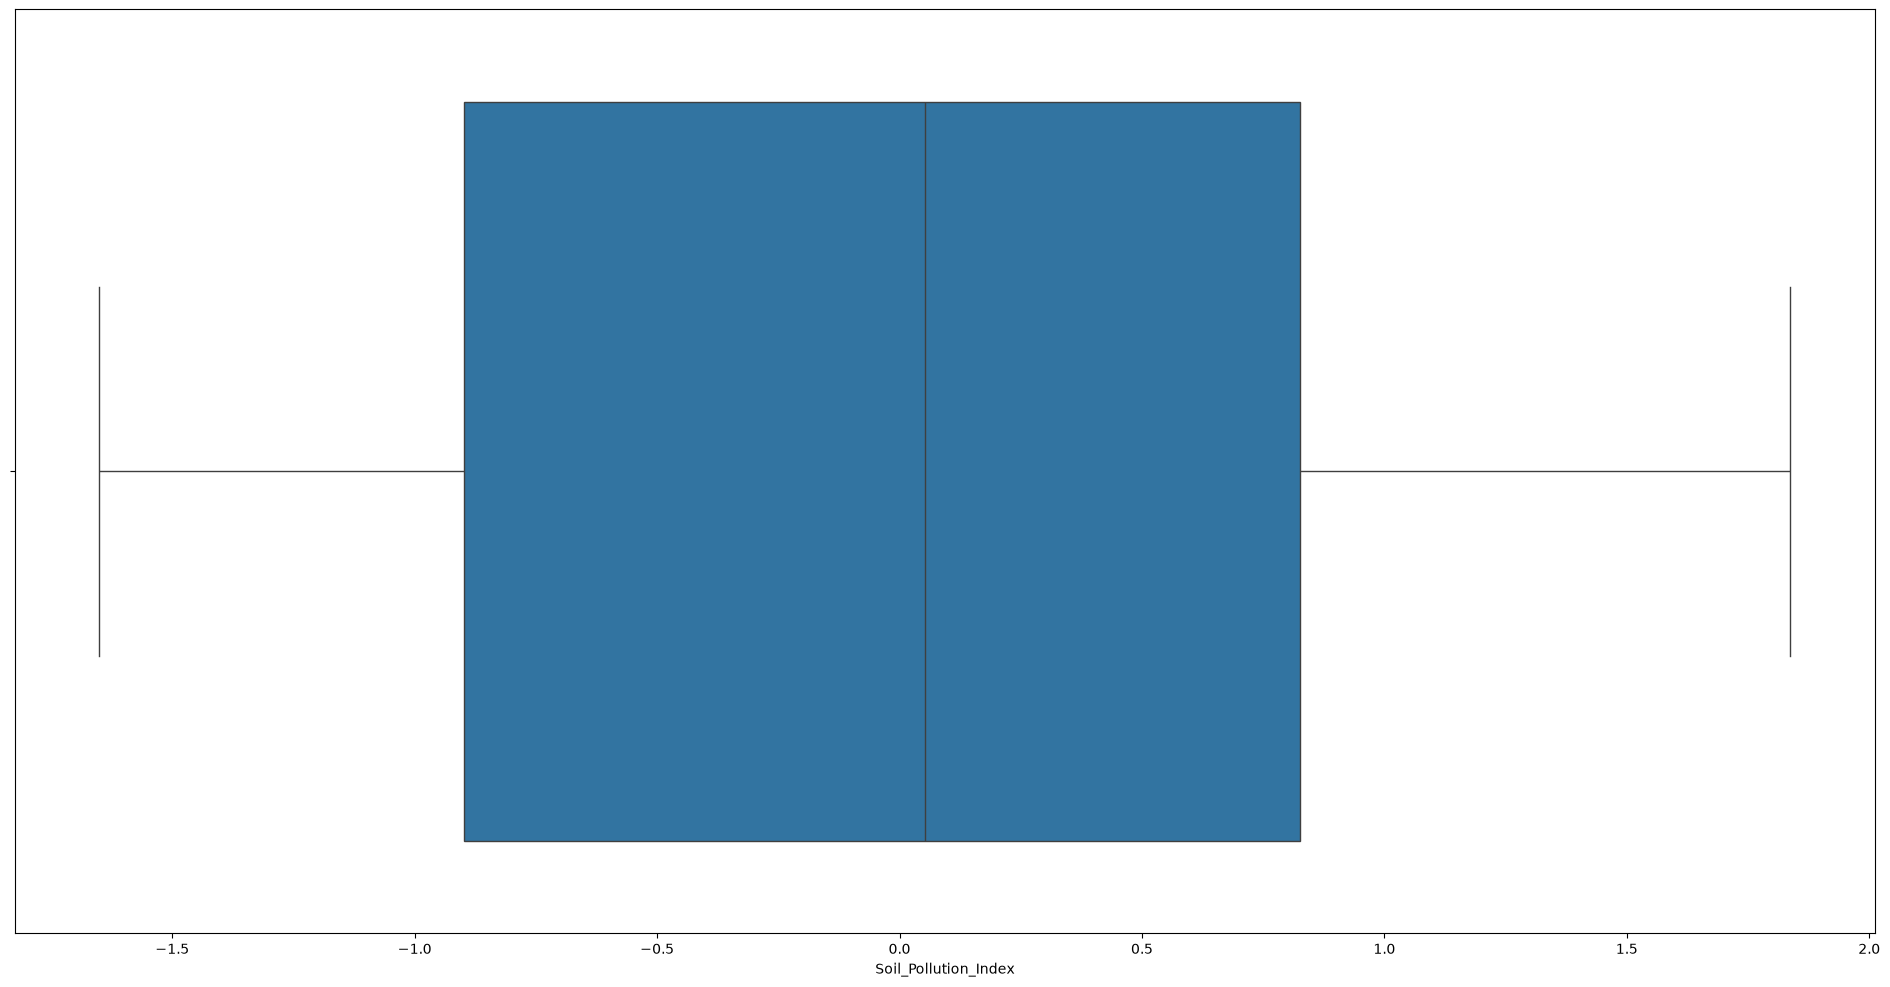

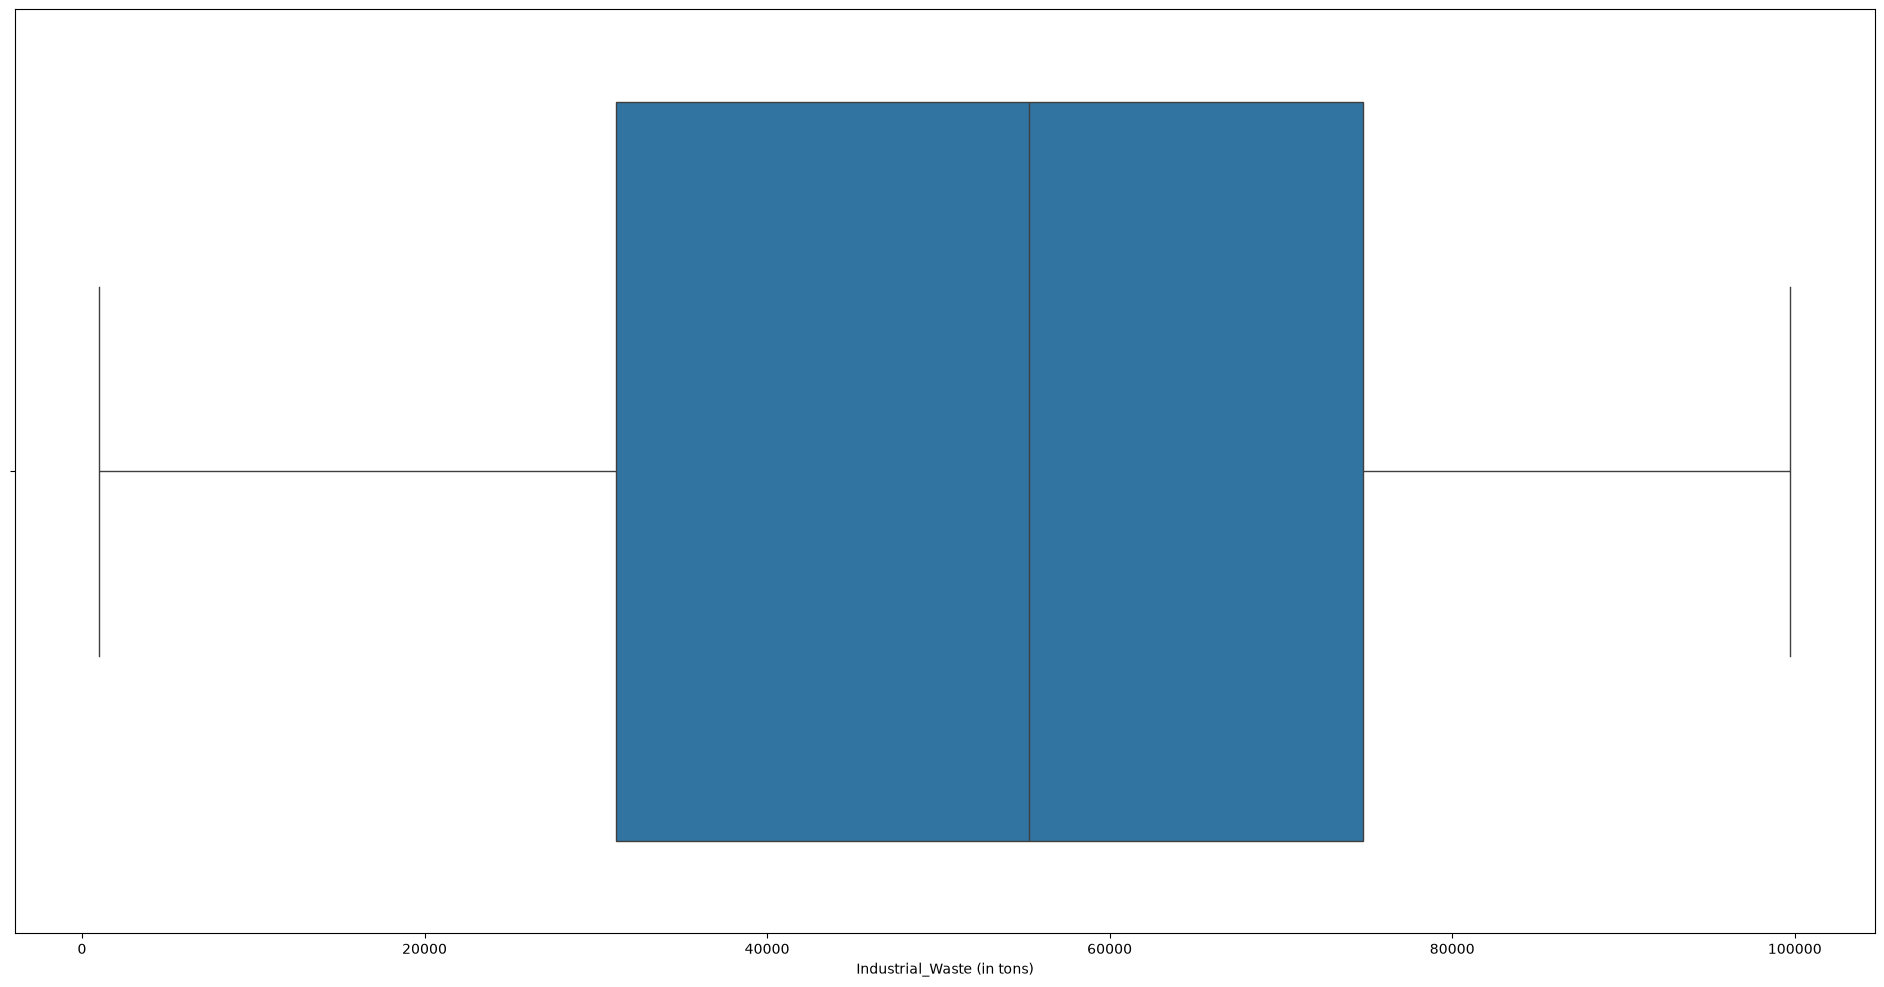

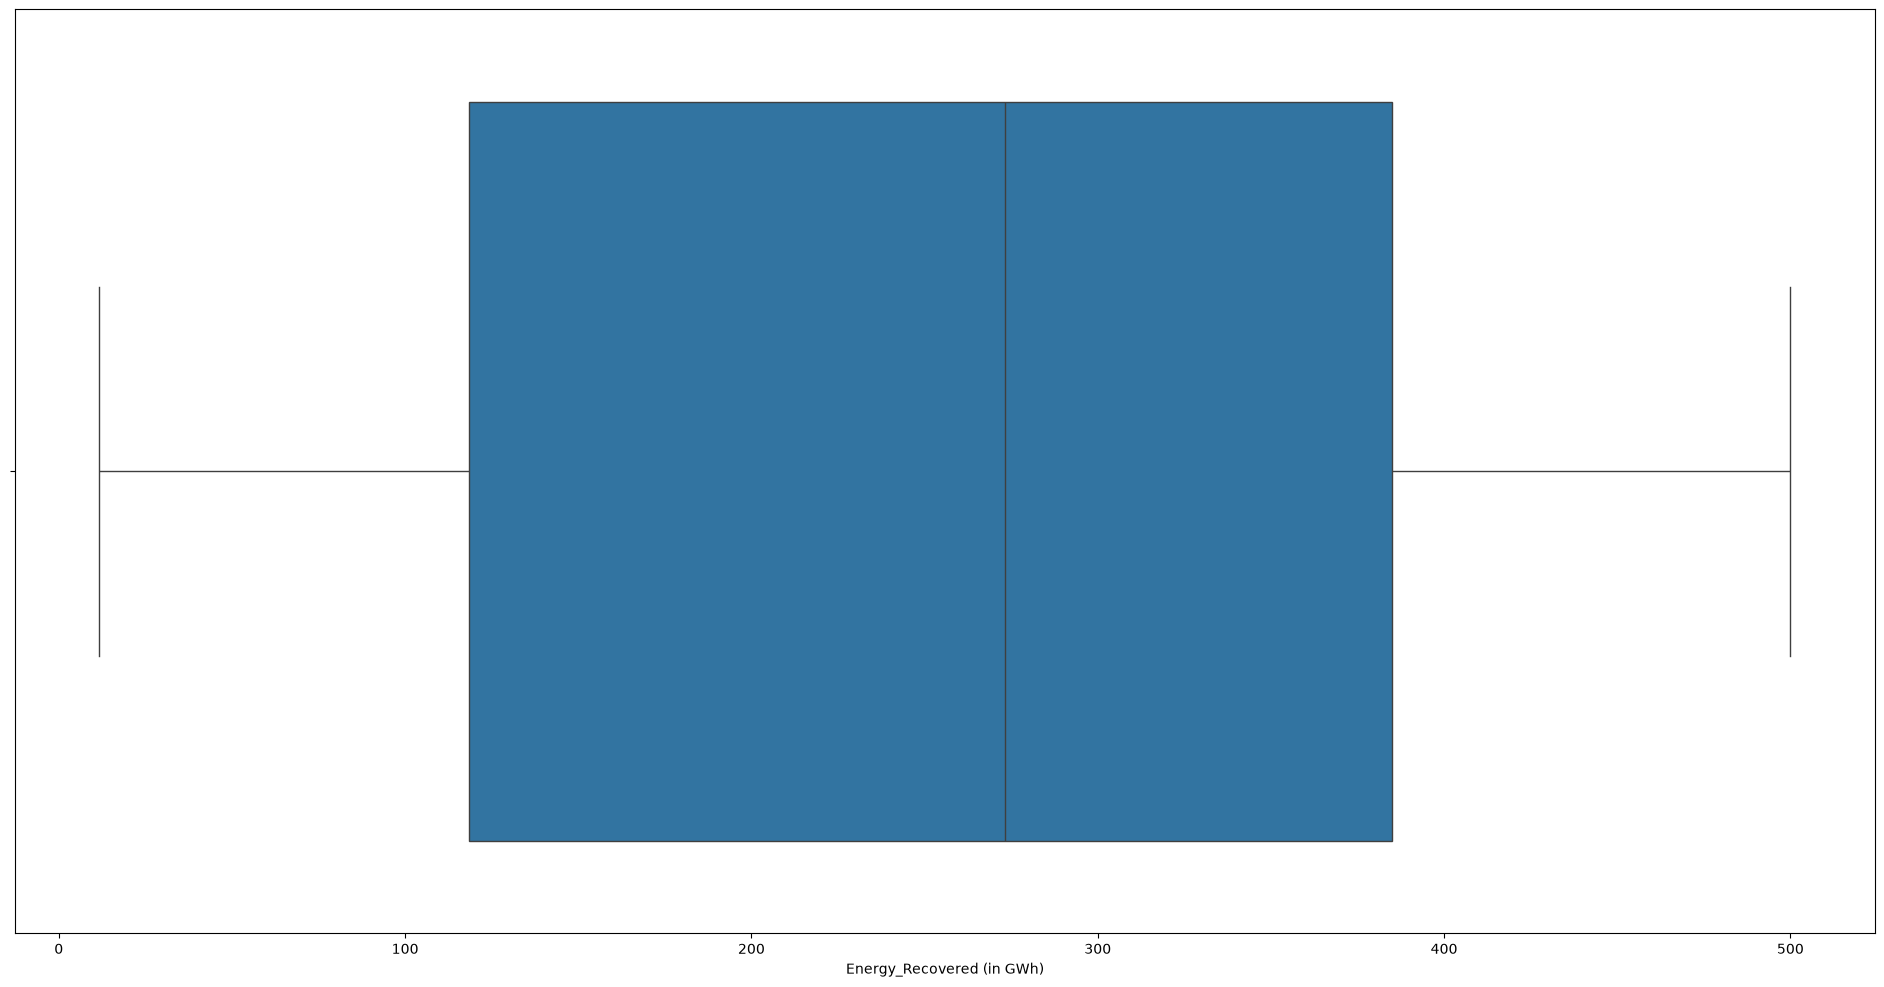

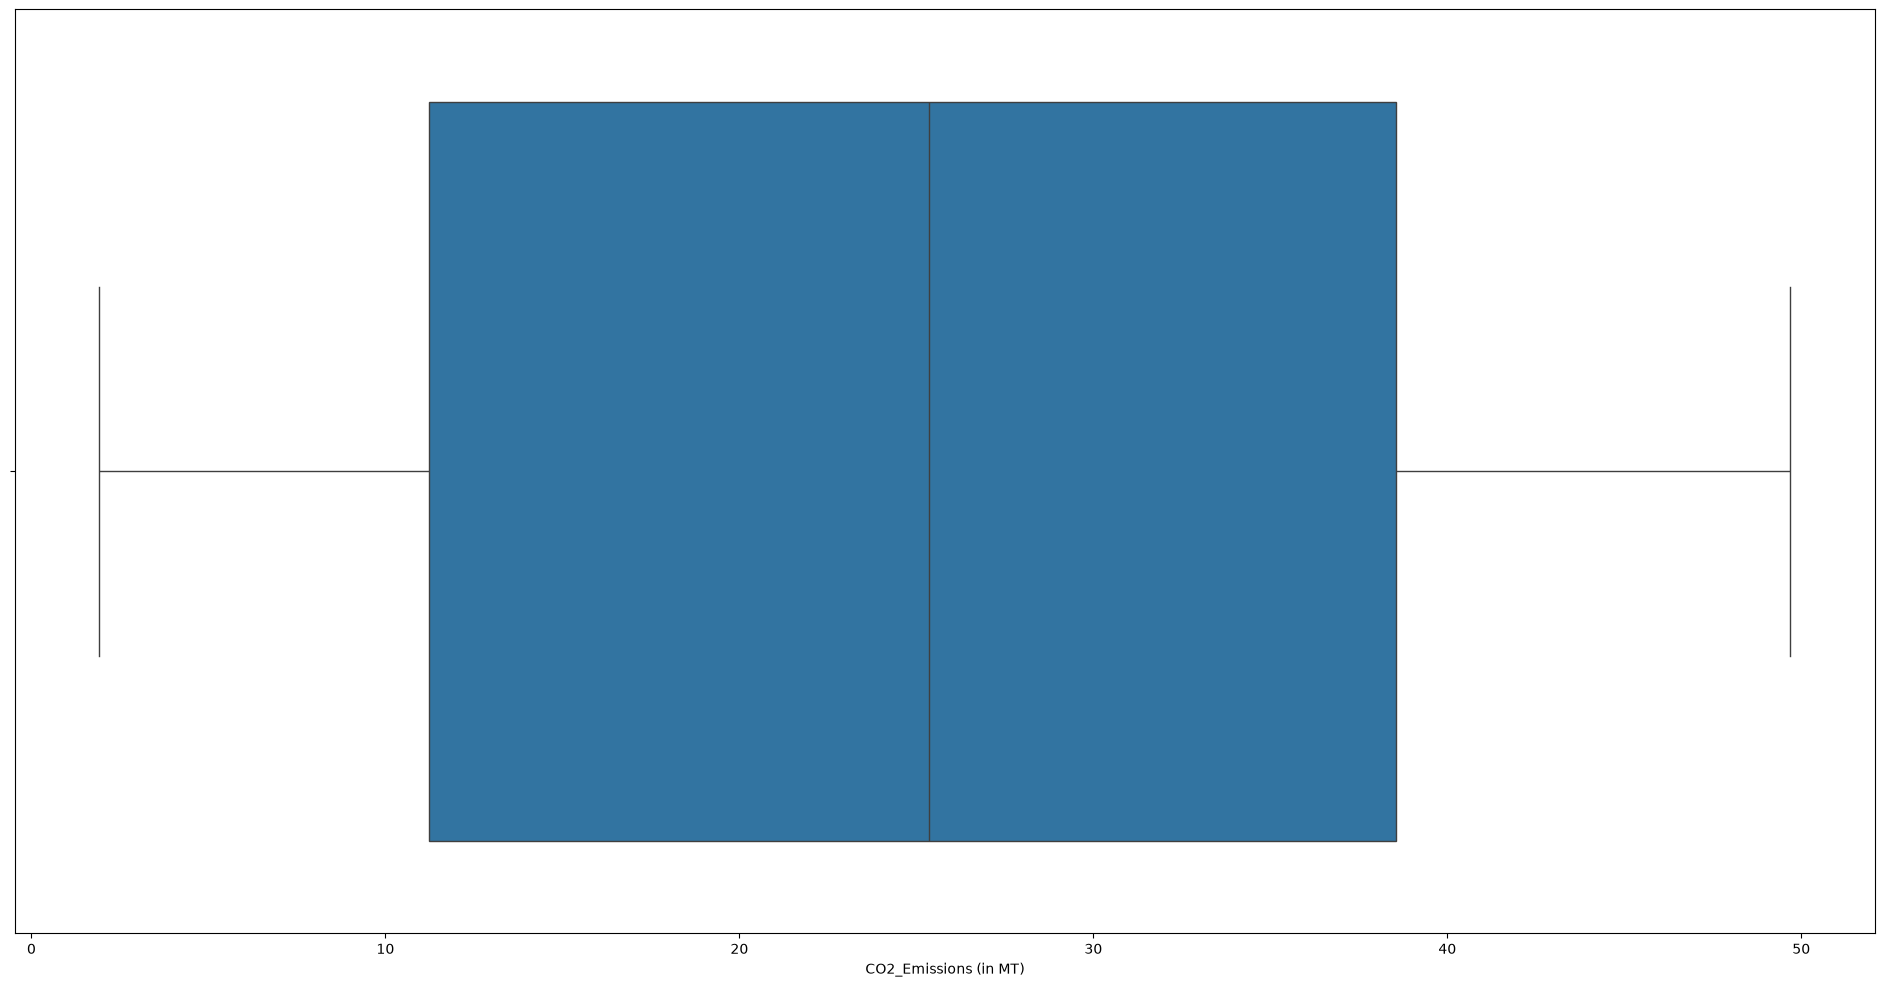

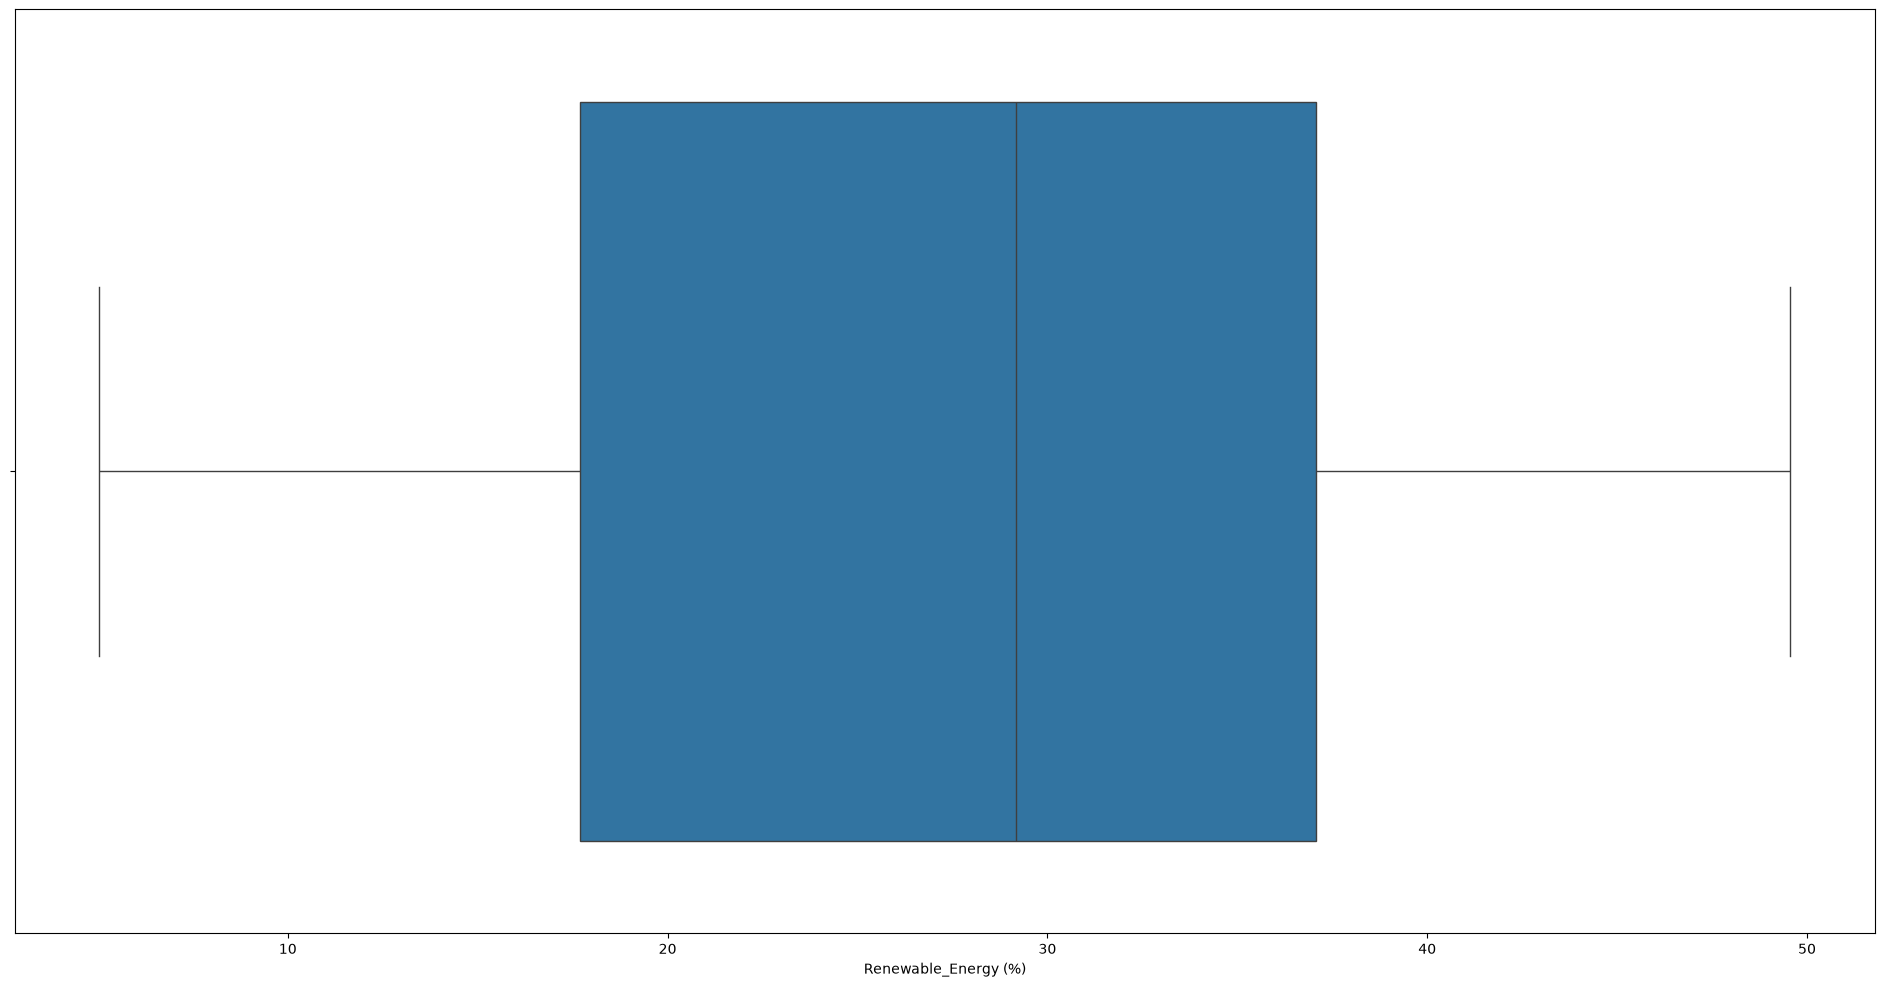

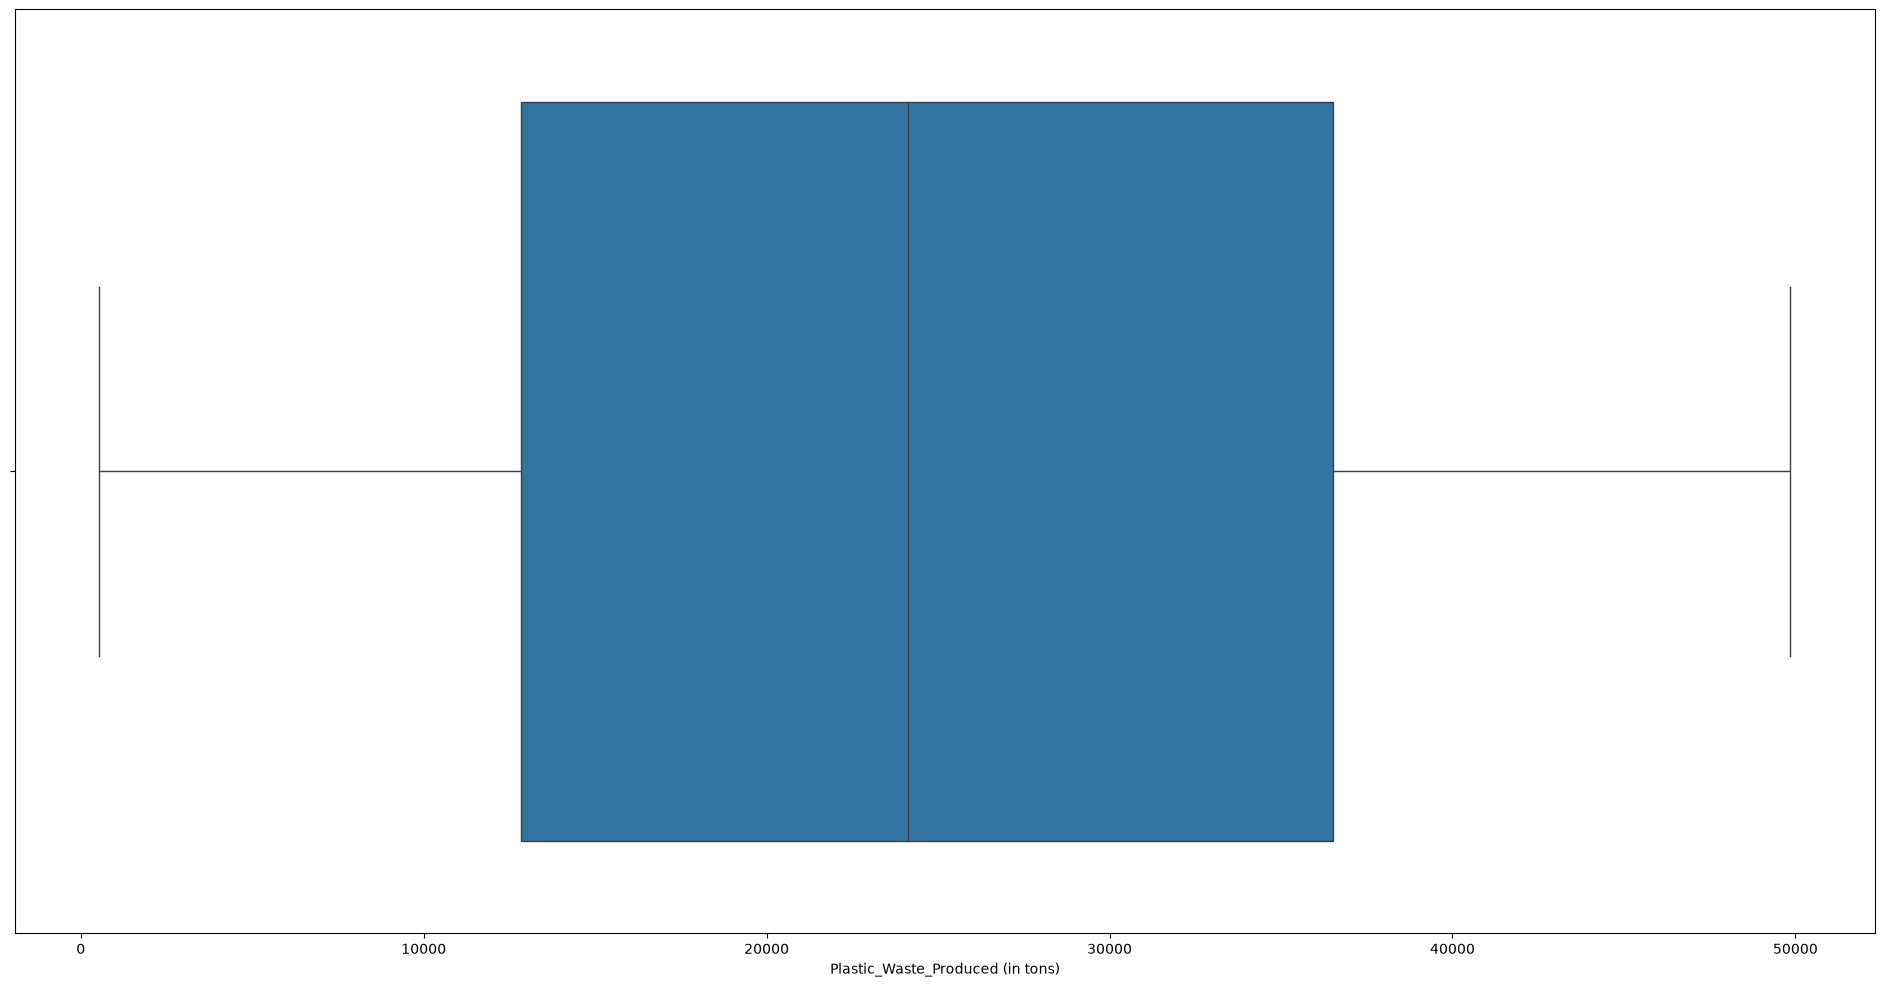

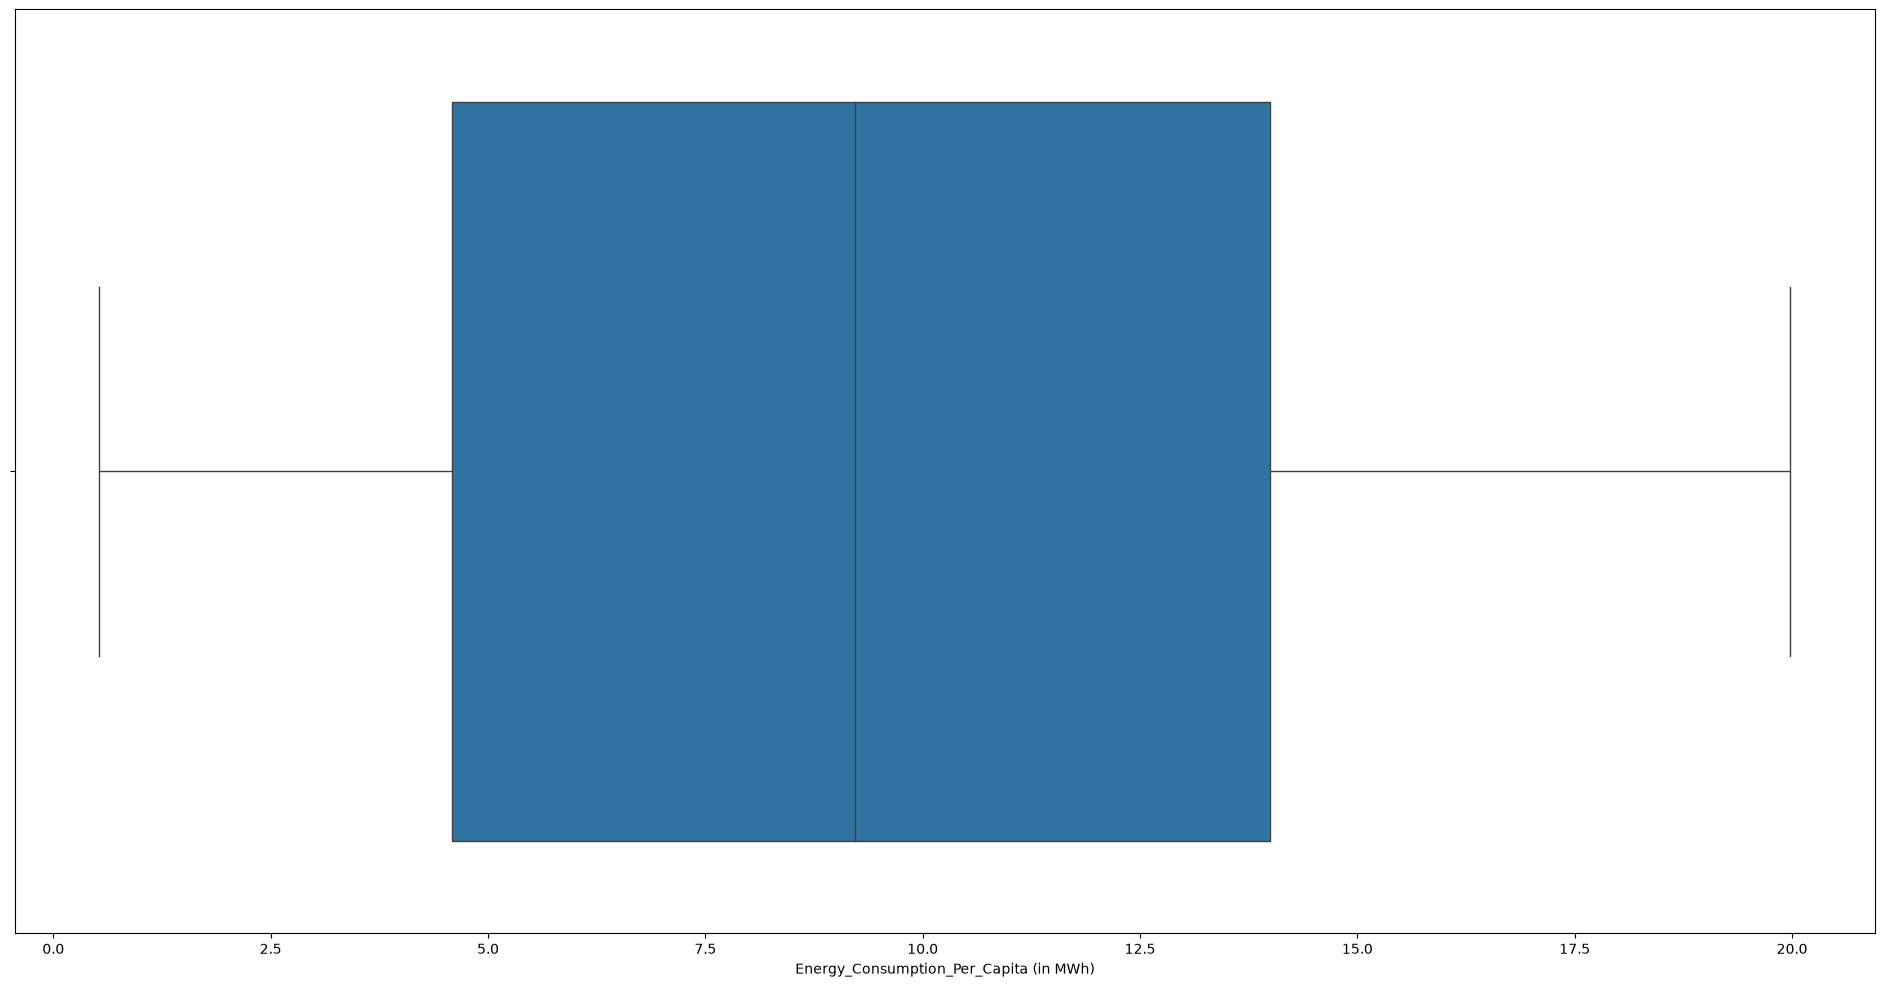

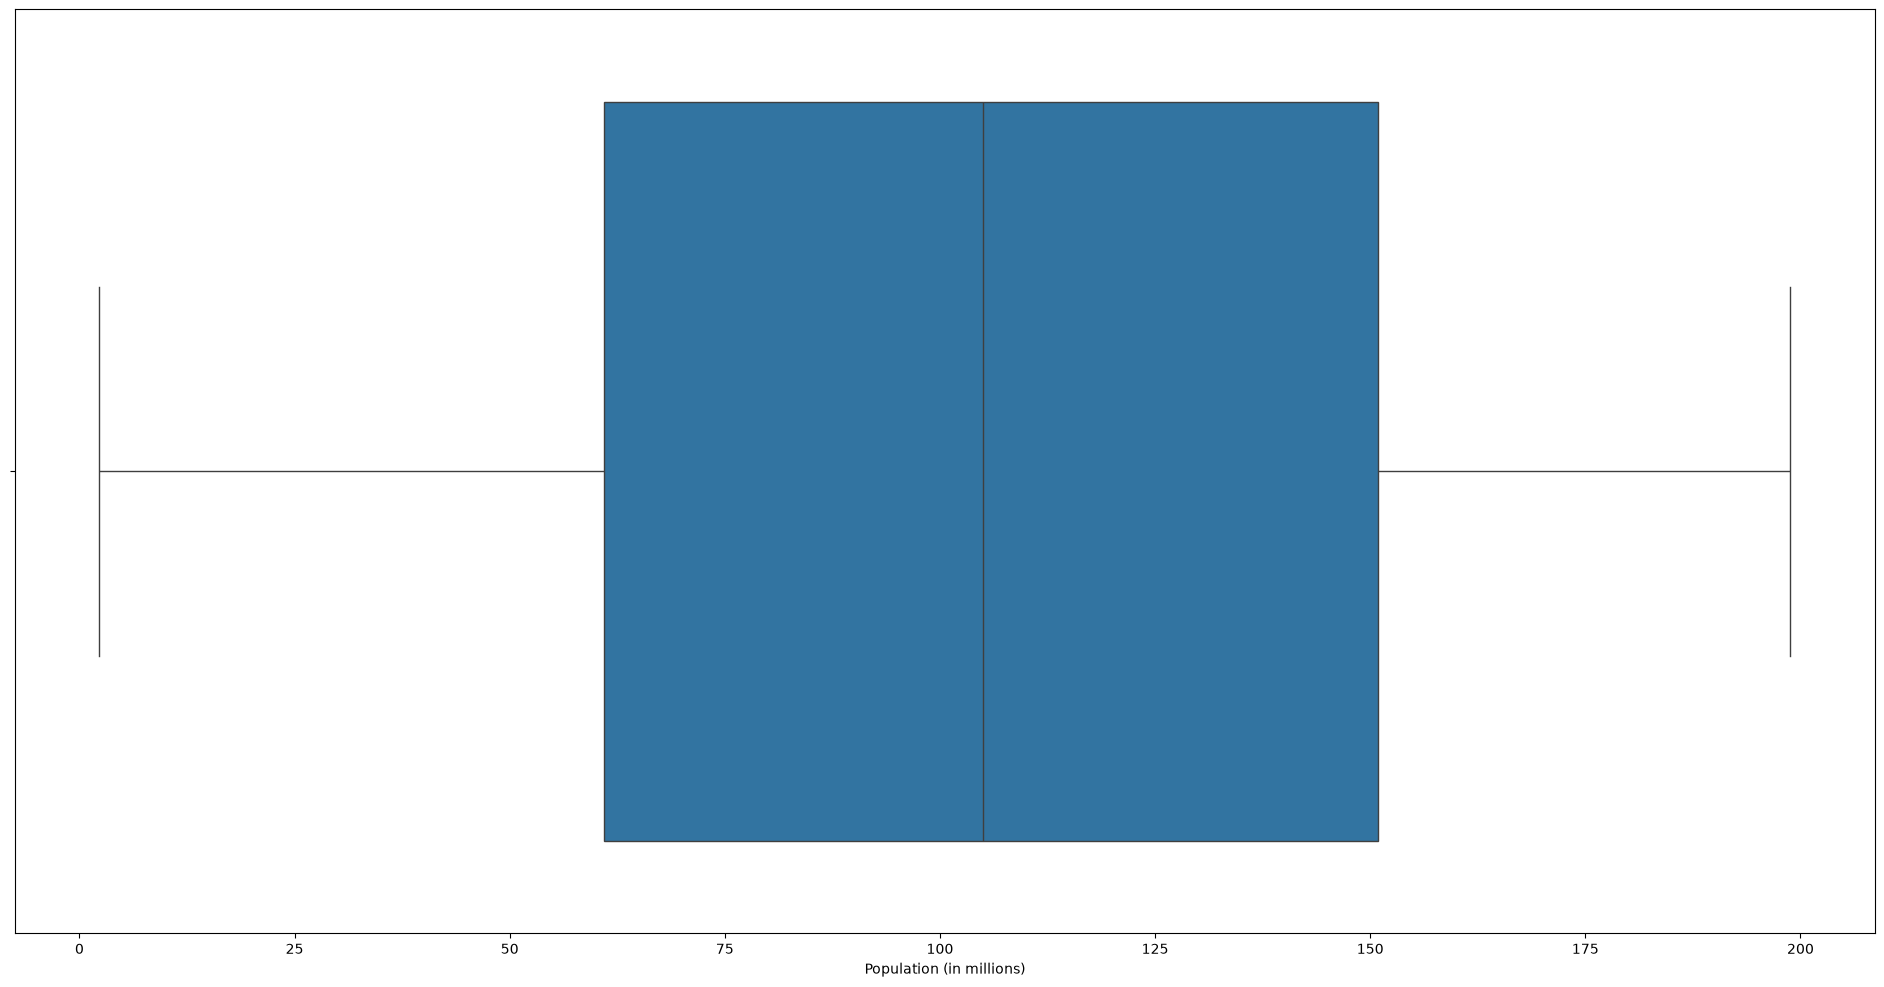

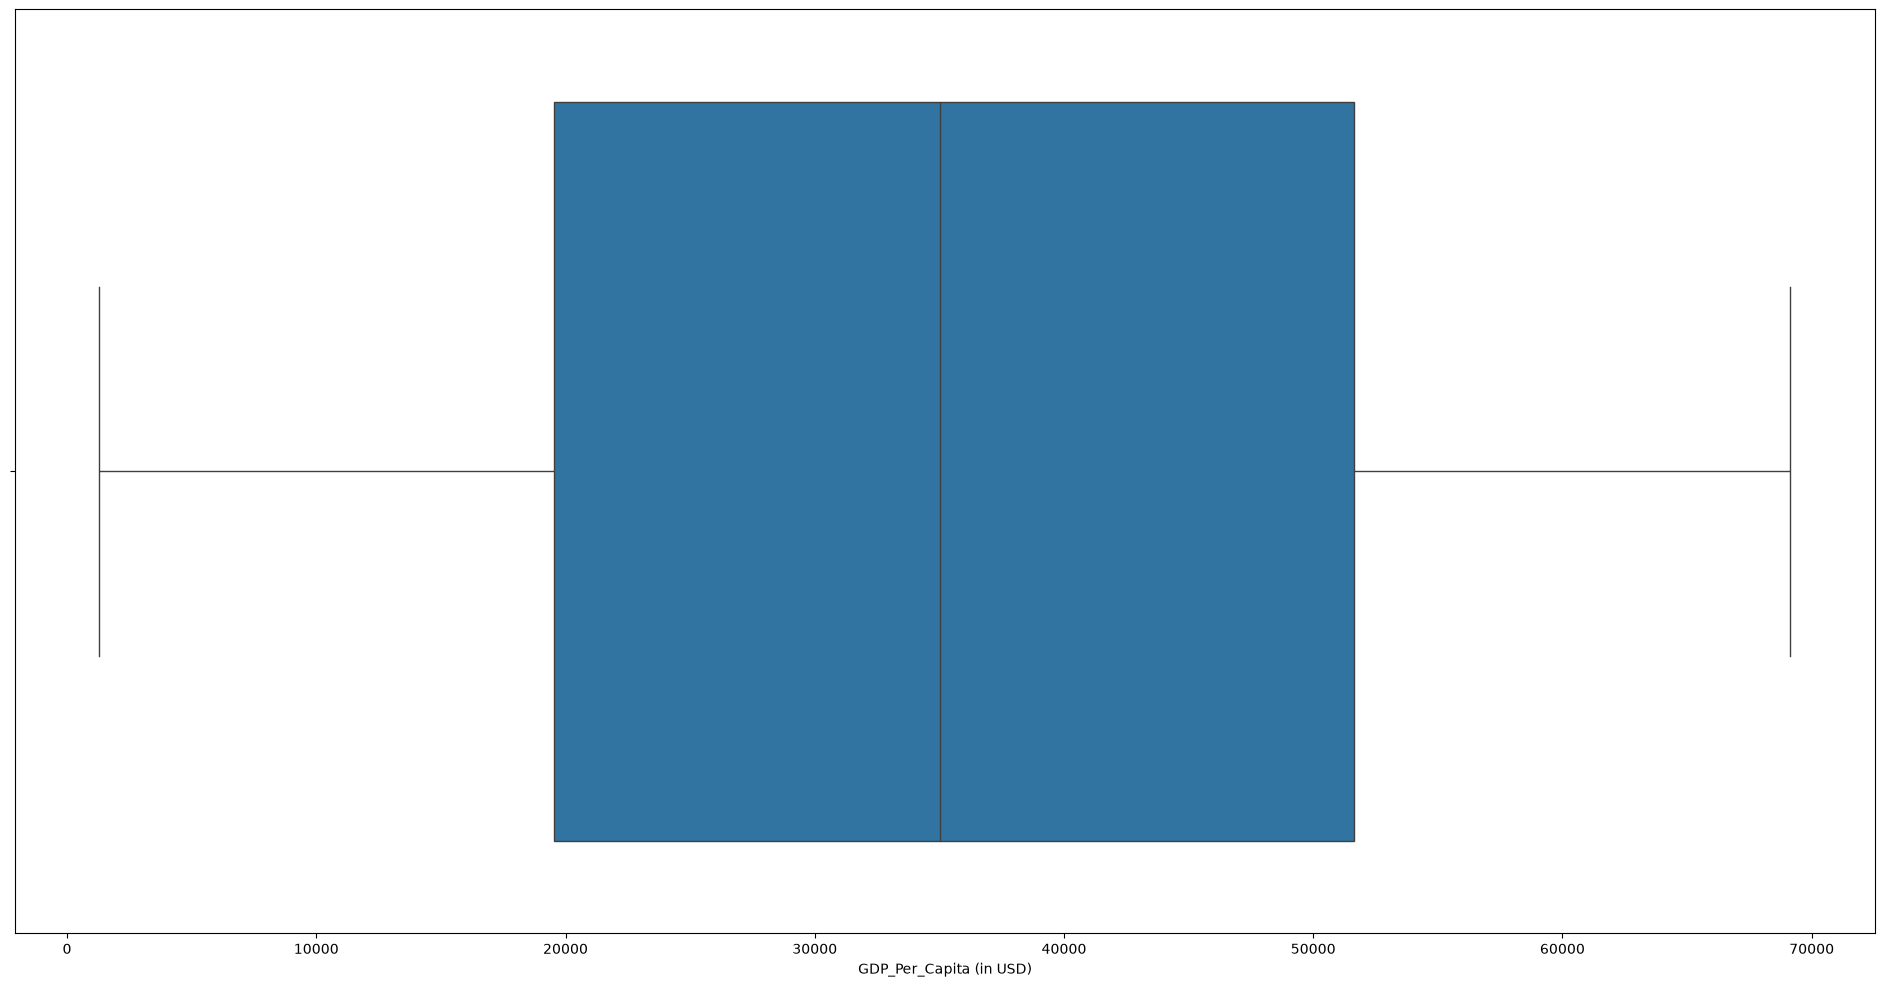

In [59]:
numeric_columns = df_new.select_dtypes(include='number').columns
for num_cols in numeric_columns:
    plt.figure(figsize=(24,12))
    sns.boxplot(x = df_new[num_cols] )

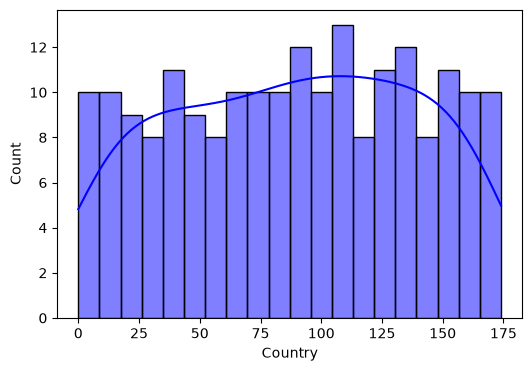

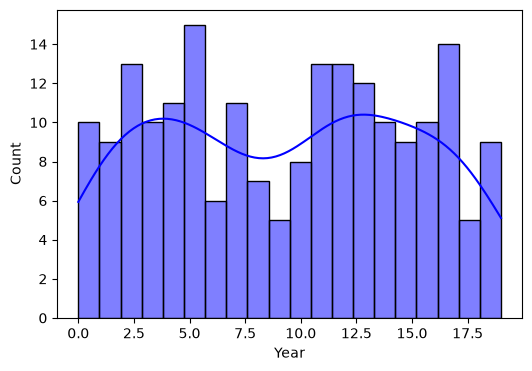

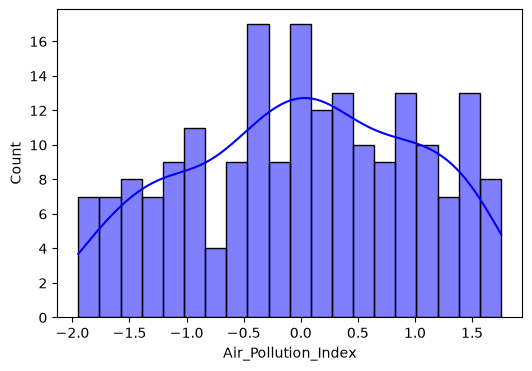

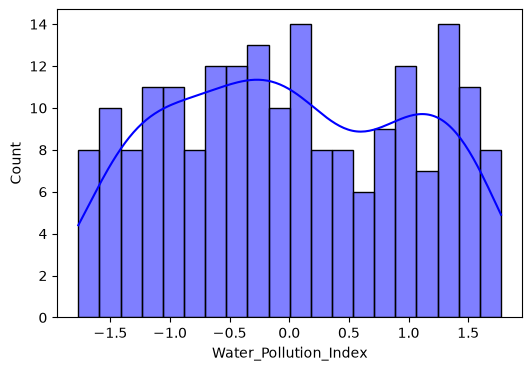

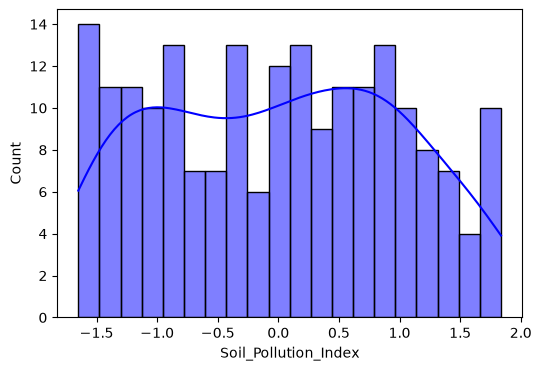

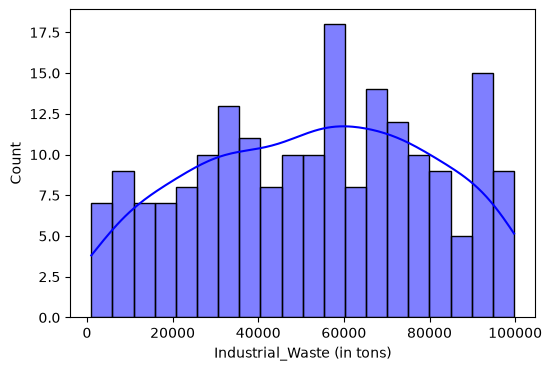

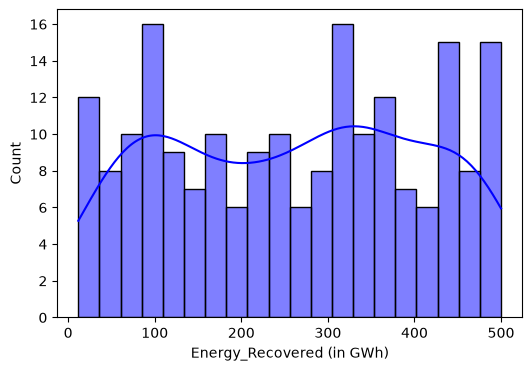

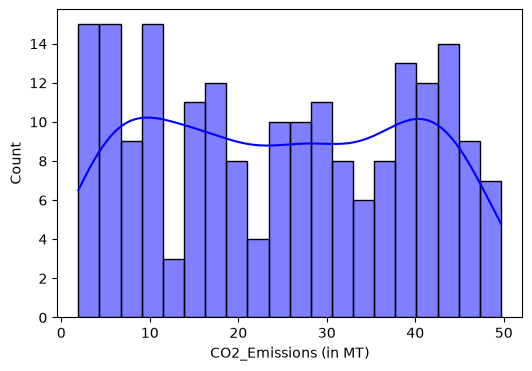

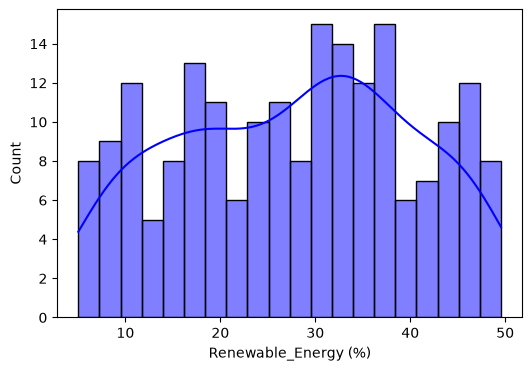

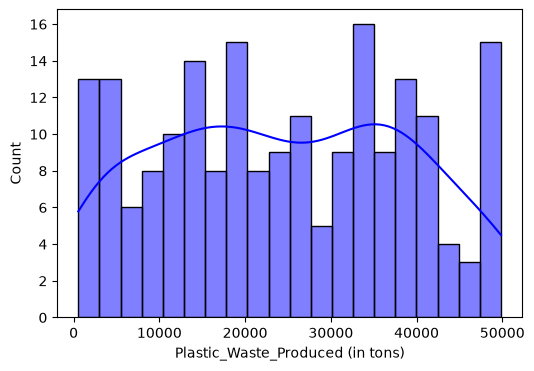

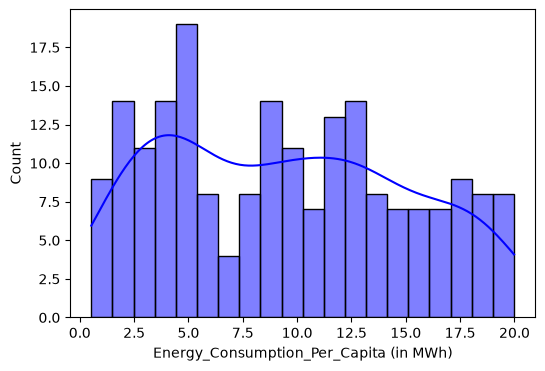

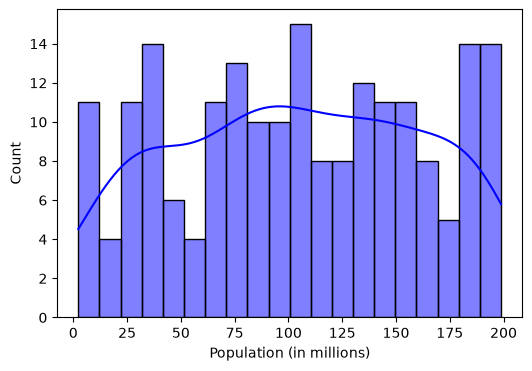

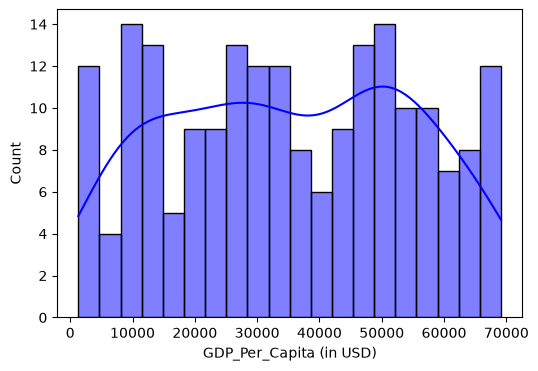

In [60]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_new[num_cols] ,kde = True,bins = 20 , color="blue"  )

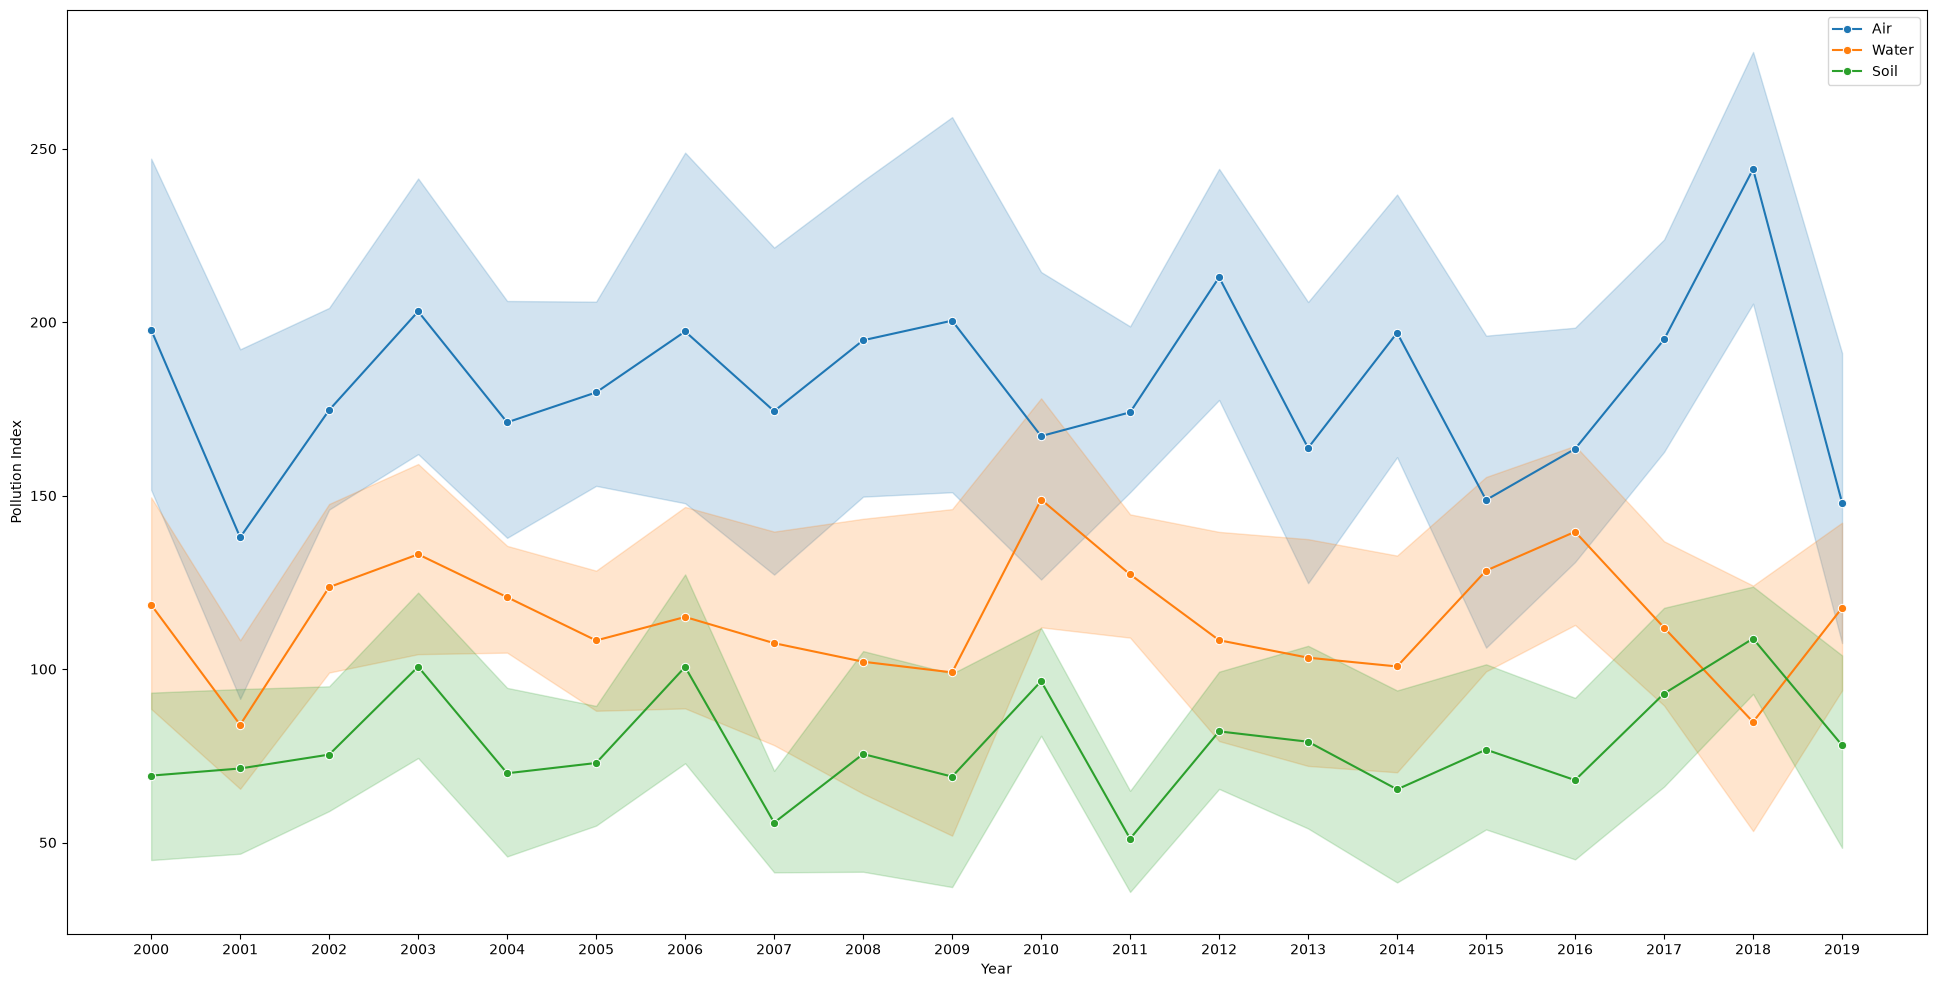

In [61]:
plt.figure(figsize=(24,12))

sns.lineplot(data=df,x='Year',y='Air_Pollution_Index',label='Air', marker='o')
sns.lineplot(data=df,x='Year',y='Water_Pollution_Index',label='Water', marker= 'o')
sns.lineplot(data=df,x='Year',y='Soil_Pollution_Index',label='Soil', marker ="o")

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Observation we get :
- Air Pollution (Blue Line): Generally fluctuating more, major peaks around 2003, 2006, 2009, 2012, and a maximum overall peak in 2018.

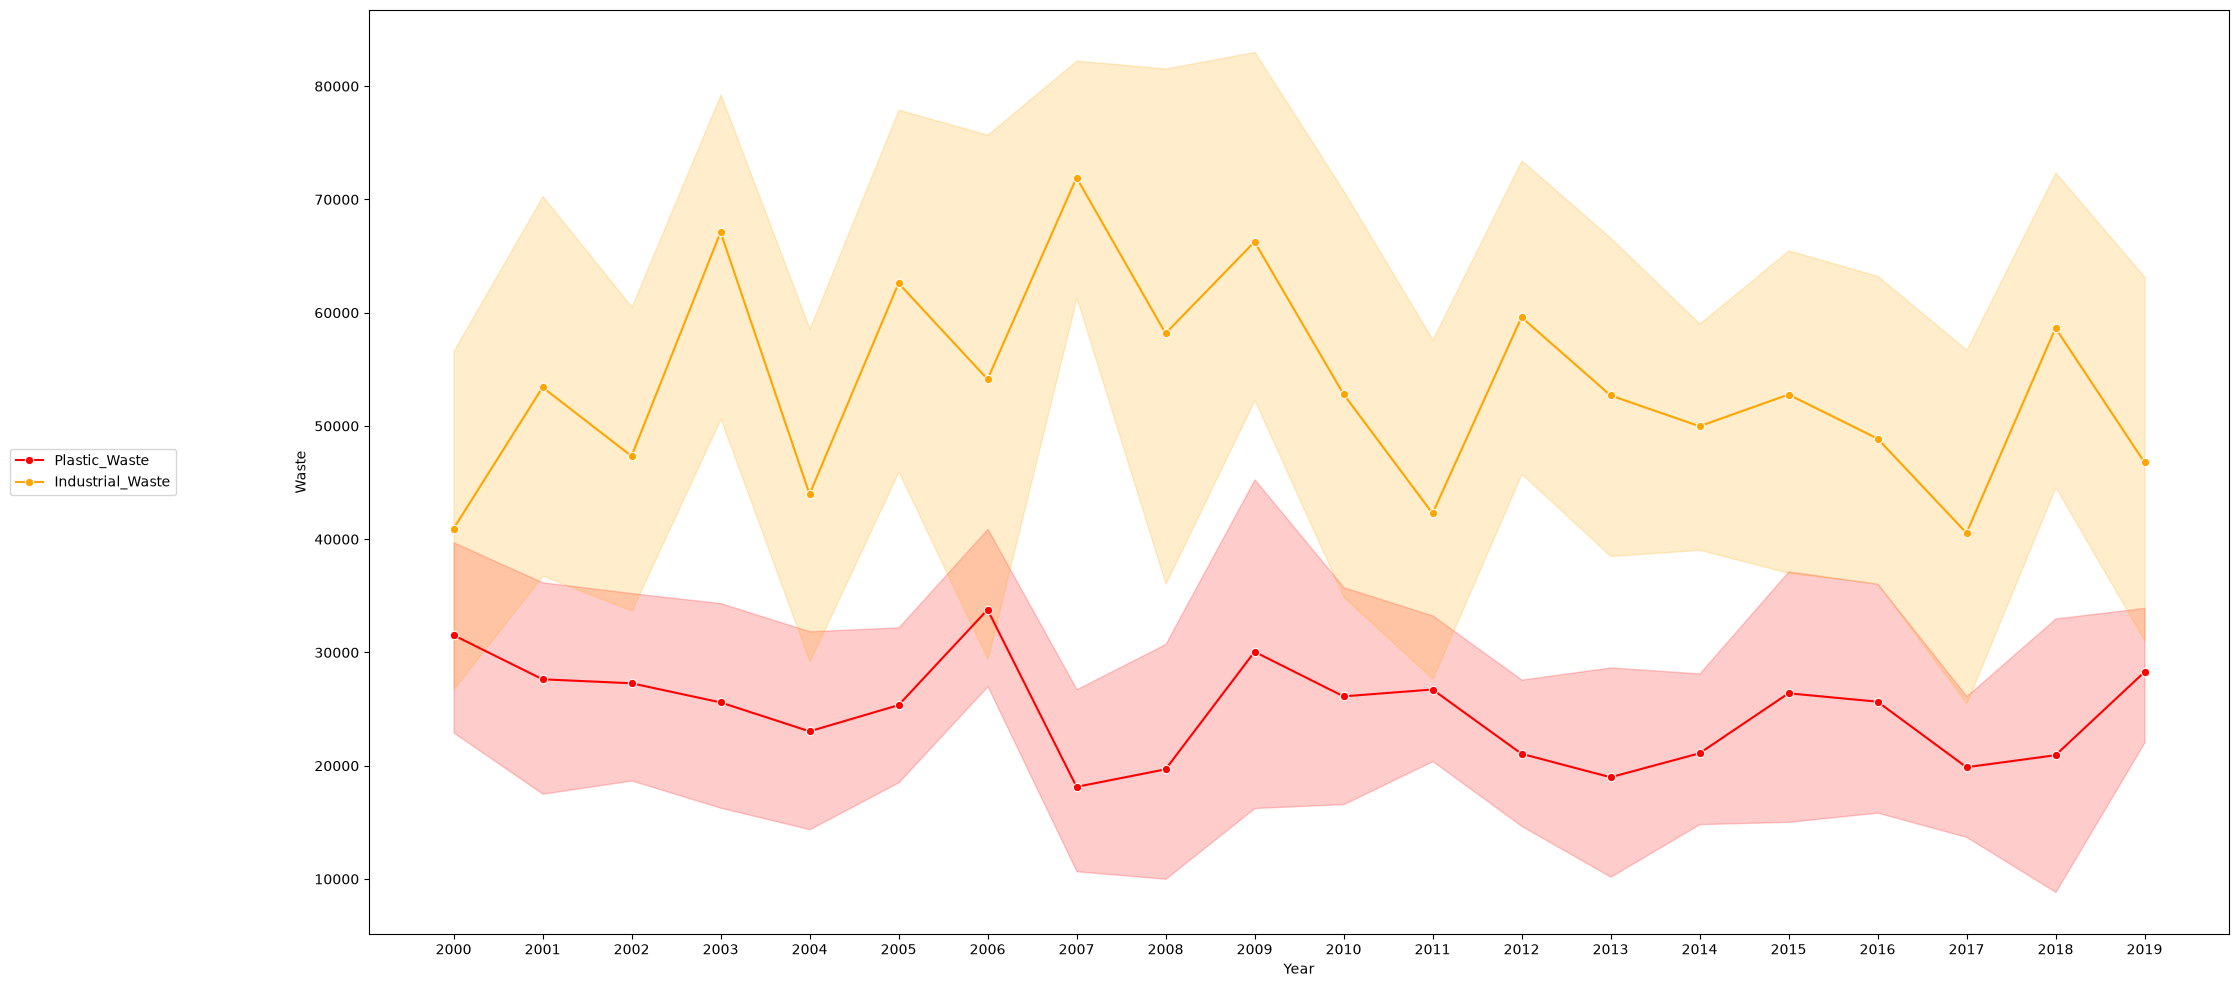

In [62]:
plt.figure(figsize=(24,12))


sns.lineplot(data=df,x='Year',y='Plastic_Waste_Produced (in tons)',label='Plastic_Waste', marker= 'o' , color='red')
sns.lineplot(data=df,x='Year',y='Industrial_Waste (in tons)',label='Industrial_Waste', marker ="o", color='orange')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Waste")

plt.legend(loc='center right', bbox_to_anchor=(-0.1, 0.5))
plt.show()


### Industrial Waste (Orange Line): Consistently remains significantly higher than plastic waste, fluctuating between roughly 40,000 and 72,000 units.

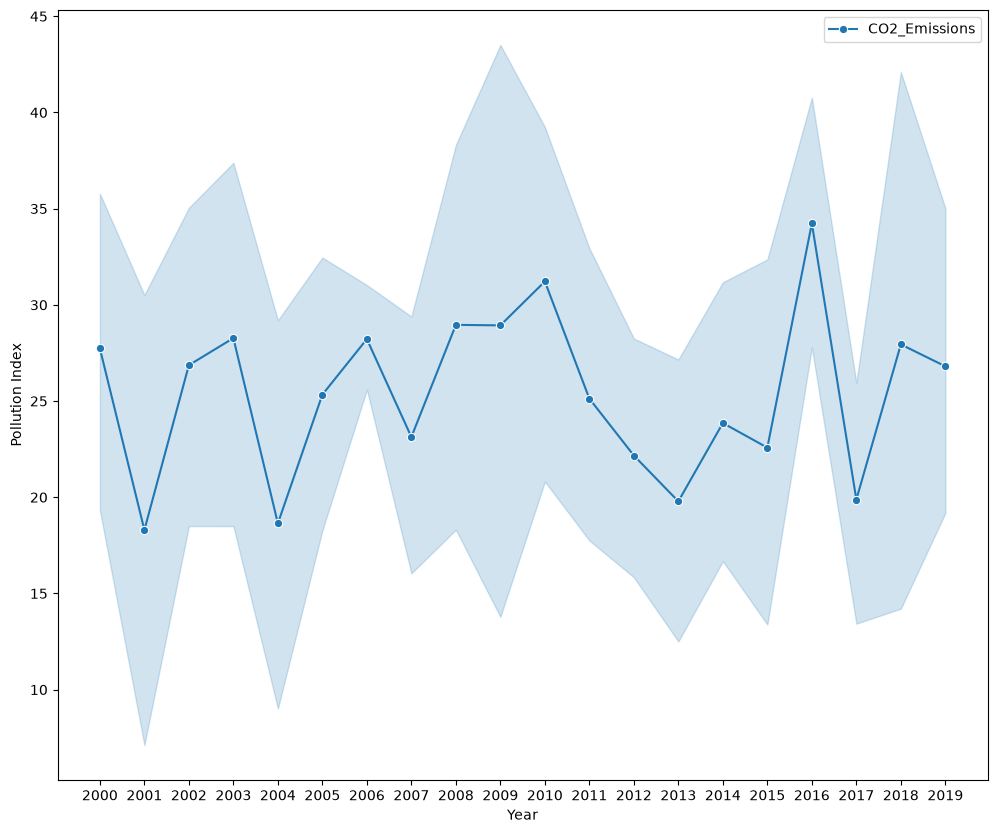

In [63]:
plt.figure(figsize=(12,10))

sns.lineplot(data=df,x='Year',y='CO2_Emissions (in MT)',label='CO2_Emissions', marker='o')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Values: $\text{CO}_2$ emissions fluctuate mostly between 18 and 34 units across the 20-year period.

In [64]:
df['Average_Pollution'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

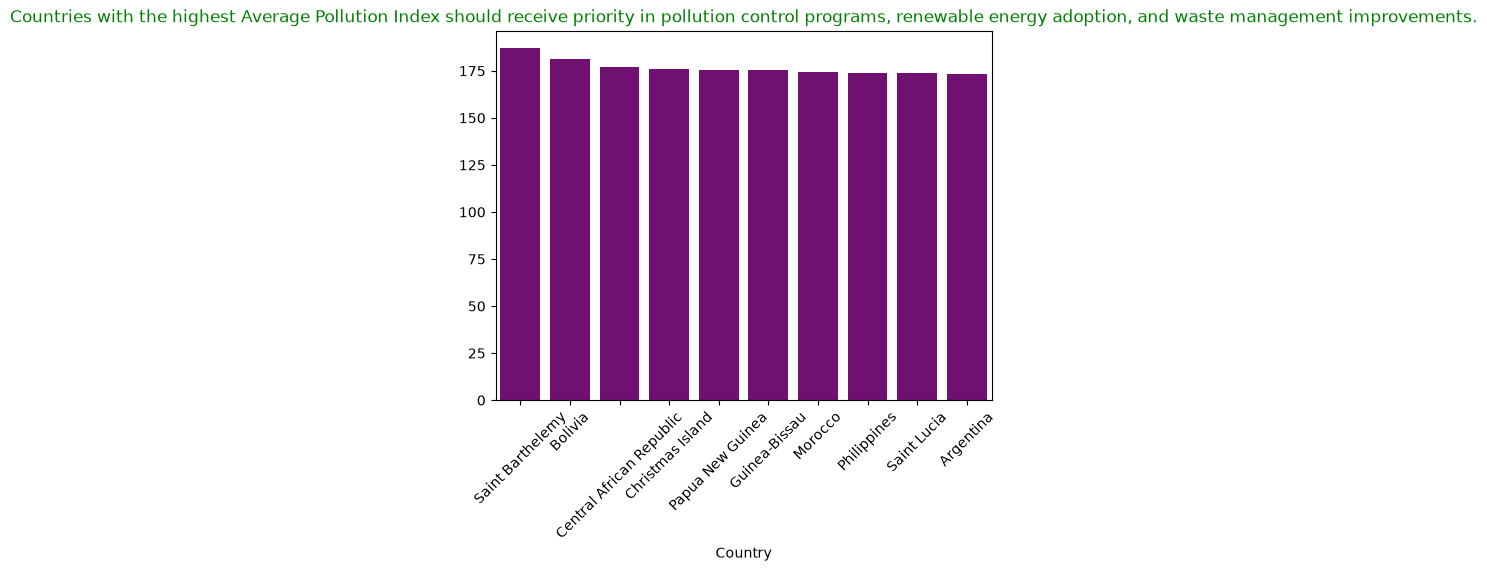

In [65]:
top10 = df.groupby('Country')['Average_Pollution'].mean().sort_values(ascending=False).head(10) # take help here :)

sns.barplot(x=top10.index, y=top10.values , color='purple')
plt.xticks(rotation=45)
plt.title("Countries with the highest Average Pollution Index should receive priority in pollution control programs, renewable energy adoption, and waste management improvements.", color="green")
plt.show()

Step 3 - Feature Engineering

In [66]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


In [67]:
yearly_trends = df.groupby("Year" , as_index=False)[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Average_Pollution",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Average_Pollution,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,128.530667,296.889000
1,2001,137.964444,83.933333,71.340000,97.745926,288.877778
2,2002,174.661538,123.617692,75.344615,124.541282,259.750769
3,2003,203.103000,133.080000,100.687000,145.623333,208.139000
4,2004,171.120909,120.719091,69.959091,120.599697,186.458182


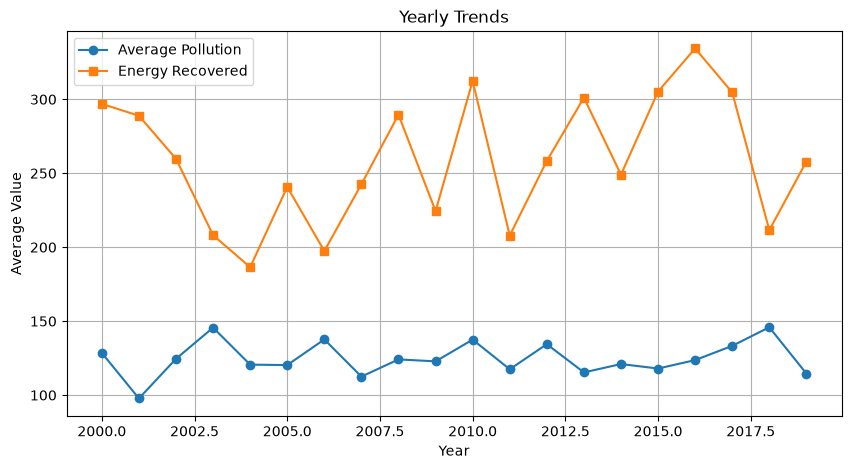

In [68]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends["Year"],
         yearly_trends["Average_Pollution"],
         marker='o',
         label="Average Pollution")

plt.plot(yearly_trends["Year"],
         yearly_trends["Energy_Recovered (in GWh)"],
         marker='s',
         label="Energy Recovered")

plt.xlabel("Year")
plt.ylabel("Average Value")
plt.title("Yearly Trends")
plt.legend()
plt.grid(True)

plt.show()

In [69]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


In [70]:
from mlxtend.frequent_patterns import apriori, association_rules

In [71]:
columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'CO2_Emissions (in MT)',
    'Industrial_Waste (in tons)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Renewable_Energy (%)'
]

df = df[columns]

In [72]:
# Create binary features using threshold (mean)
df_bin = pd.DataFrame()

for col in df.columns:
    threshold = df[col].mean()
    df_bin[col + "_HIGH"] = (df[col] > threshold).astype(int)

df_bin.head()

,Air_Pollution_Index_HIGH,Water_Pollution_Index_HIGH,Soil_Pollution_Index_HIGH,CO2_Emissions (in MT)_HIGH,Industrial_Waste (in tons)_HIGH,Plastic_Waste_Produced (in tons)_HIGH,Energy_Consumption_Per_Capita (in MWh)_HIGH,Renewable_Energy (%)_HIGH
0,1,1,0,0,1,1,1,1
1,0,0,1,0,1,1,0,1
2,0,0,1,1,1,0,1,0
3,1,0,1,0,1,0,0,0
4,0,1,1,0,1,1,1,1


In [73]:
df_bin.describe()

,Air_Pollution_Index_HIGH,Water_Pollution_Index_HIGH,Soil_Pollution_Index_HIGH,CO2_Emissions (in MT)_HIGH,Industrial_Waste (in tons)_HIGH,Plastic_Waste_Produced (in tons)_HIGH,Energy_Consumption_Per_Capita (in MWh)_HIGH,Renewable_Energy (%)_HIGH
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.00000,200.000000,200.000000
mean,0.515000,0.485000,0.515000,0.50500,0.535000,0.49500,0.485000,0.530000
std,0.501029,0.501029,0.501029,0.50123,0.500025,0.50123,0.501029,0.500352
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,1.00000,1.000000,0.00000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000


In [74]:
frequent_itemsets = apriori(
    df_bin,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

In [75]:
frequent_itemsets['length'].value_counts()

length
4    68
3    56
2    28
1     8
5     4
Name: count, dtype: int64

In [76]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

In [77]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Industrial_Waste (in tons)_HIGH}),frozenset({Air_Pollution_Index_HIGH}),0.535,0.515,0.280,0.523364,1.016242,1.0,0.004475,1.017549,0.034370,0.363636,0.017246,0.533527
1,frozenset({Air_Pollution_Index_HIGH}),frozenset({Industrial_Waste (in tons)_HIGH}),0.515,0.535,0.280,0.543689,1.016242,1.0,0.004475,1.019043,0.032953,0.363636,0.018687,0.533527
2,frozenset({Air_Pollution_Index_HIGH}),frozenset({Plastic_Waste_Produced (in tons)_HI...,0.515,0.495,0.265,0.514563,1.039521,1.0,0.010075,1.040300,0.078389,0.355705,0.038739,0.524958
3,frozenset({Plastic_Waste_Produced (in tons)_HI...,frozenset({Air_Pollution_Index_HIGH}),0.495,0.515,0.265,0.535354,1.039521,1.0,0.010075,1.043804,0.075285,0.355705,0.041966,0.524958
4,frozenset({Air_Pollution_Index_HIGH}),frozenset({Renewable_Energy (%)_HIGH}),0.515,0.530,0.295,0.572816,1.080784,1.0,0.022050,1.100227,0.154115,0.393333,0.091097,0.564710


In [78]:
rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
752,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...","frozenset({Air_Pollution_Index_HIGH, Soil_Poll...",0.245,0.120,0.055,0.224490,1.870748,1.0,0.025600,1.134737,0.616496,0.177419,0.118738,0.341412
741,"frozenset({Air_Pollution_Index_HIGH, Soil_Poll...","frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.120,0.245,0.055,0.458333,1.870748,1.0,0.025600,1.393846,0.528926,0.177419,0.282561,0.341412
738,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...","frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...",0.125,0.255,0.055,0.440000,1.725490,1.0,0.023125,1.330357,0.480519,0.169231,0.248322,0.327843
755,"frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...","frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.255,0.125,0.055,0.215686,1.725490,1.0,0.023125,1.115625,0.564369,0.169231,0.103641,0.327843
801,frozenset({Energy_Consumption_Per_Capita (in M...,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.120,0.245,0.050,0.416667,1.700680,1.0,0.020600,1.294286,0.468182,0.158730,0.227373,0.310374
782,"frozenset({Renewable_Energy (%)_HIGH, Soil_Pol...",frozenset({Energy_Consumption_Per_Capita (in M...,0.245,0.120,0.050,0.204082,1.700680,1.0,0.020600,1.105641,0.545695,0.158730,0.095547,0.310374
771,frozenset({Energy_Consumption_Per_Capita (in M...,"frozenset({Renewable_Energy (%)_HIGH, Soil_Pol...",0.120,0.245,0.050,0.416667,1.700680,1.0,0.020600,1.294286,0.468182,0.158730,0.227373,0.310374
812,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...",frozenset({Energy_Consumption_Per_Capita (in M...,0.245,0.120,0.050,0.204082,1.700680,1.0,0.020600,1.105641,0.545695,0.158730,0.095547,0.310374
748,"frozenset({Air_Pollution_Index_HIGH, Soil_Poll...","frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.255,0.130,0.055,0.215686,1.659125,1.0,0.021850,1.109250,0.533252,0.166667,0.098490,0.319382
745,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...","frozenset({Air_Pollution_Index_HIGH, Soil_Poll...",0.130,0.255,0.055,0.423077,1.659125,1.0,0.021850,1.291333,0.456635,0.166667,0.225607,0.319382


In [79]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,frozenset({Industrial_Waste (in tons)_HIGH}),frozenset({Air_Pollution_Index_HIGH}),0.280,0.523364,1.016242
1,frozenset({Air_Pollution_Index_HIGH}),frozenset({Industrial_Waste (in tons)_HIGH}),0.280,0.543689,1.016242
2,frozenset({Air_Pollution_Index_HIGH}),frozenset({Plastic_Waste_Produced (in tons)_HI...,0.265,0.514563,1.039521
3,frozenset({Plastic_Waste_Produced (in tons)_HI...,frozenset({Air_Pollution_Index_HIGH}),0.265,0.535354,1.039521
4,frozenset({Air_Pollution_Index_HIGH}),frozenset({Renewable_Energy (%)_HIGH}),0.295,0.572816,1.080784
...,...,...,...,...,...
847,frozenset({Soil_Pollution_Index_HIGH}),"frozenset({Water_Pollution_Index_HIGH, Industr...",0.050,0.097087,1.213592
848,frozenset({Water_Pollution_Index_HIGH}),"frozenset({Industrial_Waste (in tons)_HIGH, Pl...",0.050,0.103093,1.288660
849,frozenset({Plastic_Waste_Produced (in tons)_HI...,"frozenset({Water_Pollution_Index_HIGH, Industr...",0.050,0.101010,1.443001
850,frozenset({Industrial_Waste (in tons)_HIGH}),"frozenset({Water_Pollution_Index_HIGH, Plastic...",0.050,0.093458,1.038422


In [80]:
def interpret_rules(df): 
    results = []
    for _, row in df.iterrows():
        results.append(
            f"If {set(row['antecedents'])} then {set(row['consequents'])} "
            f"(conf={row['confidence']:.2f}, lift={row['lift']:.2f})"
        )
    return results

interpretations = interpret_rules(rules)
for i in interpretations[:10]:
    print(i)

If {'Industrial_Waste (in tons)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.52, lift=1.02)
If {'Air_Pollution_Index_HIGH'} then {'Industrial_Waste (in tons)_HIGH'} (conf=0.54, lift=1.02)
If {'Air_Pollution_Index_HIGH'} then {'Plastic_Waste_Produced (in tons)_HIGH'} (conf=0.51, lift=1.04)
If {'Plastic_Waste_Produced (in tons)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.54, lift=1.04)
If {'Air_Pollution_Index_HIGH'} then {'Renewable_Energy (%)_HIGH'} (conf=0.57, lift=1.08)
If {'Renewable_Energy (%)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.56, lift=1.08)
If {'Water_Pollution_Index_HIGH'} then {'CO2_Emissions (in MT)_HIGH'} (conf=0.52, lift=1.02)
If {'CO2_Emissions (in MT)_HIGH'} then {'Water_Pollution_Index_HIGH'} (conf=0.50, lift=1.02)
If {'Water_Pollution_Index_HIGH'} then {'Industrial_Waste (in tons)_HIGH'} (conf=0.57, lift=1.06)
If {'Industrial_Waste (in tons)_HIGH'} then {'Water_Pollution_Index_HIGH'} (conf=0.51, lift=1.06)


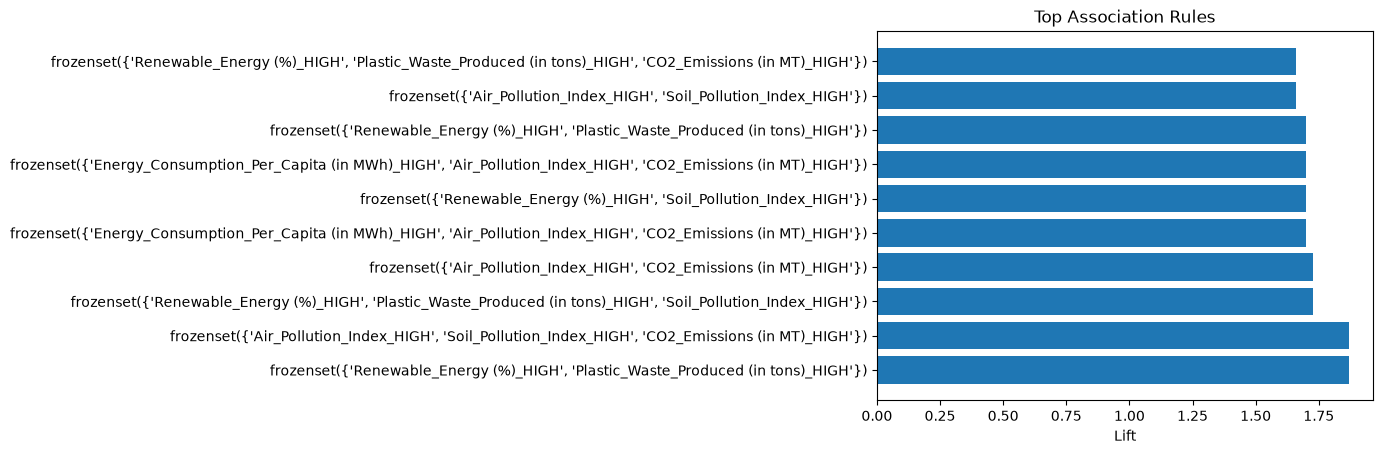

In [81]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure()
plt.barh(range(len(top_rules)), top_rules['lift'])
plt.yticks(range(len(top_rules)), top_rules['antecedents'].astype(str))
plt.xlabel("Lift")
plt.title("Top Association Rules")
plt.show()